# Notebook Description

This Jupyter Notebook presents the evaluation of the system outputs on hallucination evaluation datasets using a multi-run aggregation approach.

The notebook collects the outputs generated under different temperature values, normalizes the predictions, performs majority voting across multiple runs to obtain a final aggregated decision, and computes evaluation metrics for the system performance under each temperature setting.

In addition, the notebook computes metrics related to the behavior of the multi-run aggregation method itself, including agreement rate, consistency, prediction diversity, and other aggregation-related statistics.

The goal of this analysis is to investigate how stochastic decoding and temperature influence the robustness, stability, and overall performance of the LLM-as-a-Judge system.

In [1]:


# =========================================
# Libraries
# =========================================

import os
import re
import json
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns

from IPython.display import display

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

In [2]:
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

TASK_DIR = Path(r"C:\Users\georg\Documents\VScode\Thesis\all\old_finalresults")
DATASET_NAME = "HaluEval"

result_files = sorted(
    f for f in TASK_DIR.rglob("*.jsonl")
    if f.name.startswith("judge_")
)
for f in result_files:
    print(f.name)


def parse_filename(path):

    name = path.stem.lower()

    judge_model = re.search(
        r"judge_(.*?)_generator",
        name
    ).group(1)

    generator_model = re.search(
        r"generator_(.*?)(?:_oneshot|_multirun)",
        name
    ).group(1)

    mode = "oneshot"

    if "_multirun_" in name:
        mode = "multirun"

    temp_match = re.search(
        r"_multirun_([0-9.]+)",
        name
    )

    temperature = (
        float(temp_match.group(1))
        if temp_match
        else 0.0
    )

    return {
        "judge_model": judge_model,
        "generator_model": generator_model,
        "mode": mode,
        "temperature": temperature,
        "filename": path.name,
    }

judge_llama8_generator_mistral7_multirun_0.25_HaluEval_results.jsonl
judge_llama8_generator_mistral7_multirun_0.5_HaluEval_results.jsonl
judge_llama8_generator_mistral7_multirun_0.75_HaluEval_results.jsonl
judge_llama8_generator_mistral7_multirun_1_HaluEval_results.jsonl
judge_llama8_generator_mistral7_oneshot_HaluEval_results.jsonl
judge_mistral7_generator_mistral7_multirun_0.25_HaluEval_results.jsonl
judge_mistral7_generator_mistral7_multirun_0.5_HaluEval_results.jsonl
judge_mistral7_generator_mistral7_multirun_0.75_HaluEval_results.jsonl
judge_mistral7_generator_mistral7_multirun_1_HaluEval_results.jsonl
judge_mistral7_generator_mistral7_oneshot_all_HaluEval_results.jsonl
judge_qwen7_generator_mistral7_multirun_0.25_HaluEval_results.jsonl
judge_qwen7_generator_mistral7_multirun_0.5_HaluEval_results.jsonl
judge_qwen7_generator_mistral7_multirun_0.75_HaluEval_results.jsonl
judge_qwen7_generator_mistral7_multirun_1_HaluEval_results.jsonl
judge_qwen7_generator_mistral7_oneshot_all_HaluE

In [3]:
def read_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))

    return pd.DataFrame(rows)


all_dfs = []

for f in result_files:
    meta = parse_filename(f)
    temp_df = read_jsonl(f)

    for k, v in meta.items():
        temp_df[k] = v

    all_dfs.append(temp_df)

results_df = pd.concat(all_dfs, ignore_index=True)

print(results_df.shape)
print(results_df.columns.tolist())
results_df.head()

(242939, 11)
['id', 'prediction', 'ground_truth', 'finish_reason', 'metadata', 'run_id', 'judge_model', 'generator_model', 'mode', 'temperature', 'filename']


,id,prediction,ground_truth,finish_reason,metadata,run_id,judge_model,generator_model,mode,temperature,filename
0,1,PASS,PASS,stop,"{'generators_answer': 'PASS', 'prompt_length':...",0,llama8,mistral7,multirun,0.25,judge_llama8_generator_mistral7_multirun_0.25_...
1,1,PASS,PASS,stop,"{'generators_answer': 'PASS', 'prompt_length':...",1,llama8,mistral7,multirun,0.25,judge_llama8_generator_mistral7_multirun_0.25_...
2,1,PASS,PASS,stop,"{'generators_answer': 'PASS', 'prompt_length':...",2,llama8,mistral7,multirun,0.25,judge_llama8_generator_mistral7_multirun_0.25_...
3,1,PASS,PASS,stop,"{'generators_answer': 'PASS', 'prompt_length':...",3,llama8,mistral7,multirun,0.25,judge_llama8_generator_mistral7_multirun_0.25_...
4,1,PASS,PASS,stop,"{'generators_answer': 'PASS', 'prompt_length':...",4,llama8,mistral7,multirun,0.25,judge_llama8_generator_mistral7_multirun_0.25_...


In [4]:
metadata_df = pd.json_normalize(results_df["metadata"])
results_df = pd.concat([results_df, metadata_df], axis=1)

In [5]:
print(results_df.shape)
print(results_df.columns.tolist())
results_df.iloc[0].to_dict()

(242939, 14)
['id', 'prediction', 'ground_truth', 'finish_reason', 'metadata', 'run_id', 'judge_model', 'generator_model', 'mode', 'temperature', 'filename', 'generators_answer', 'prompt_length', 'llama_3_1_bucket']


{'id': '1',
 'prediction': 'PASS',
 'ground_truth': 'PASS',
 'finish_reason': 'stop',
 'metadata': {'generators_answer': 'PASS',
  'prompt_length': '75',
  'llama_3_1_bucket': 'short'},
 'run_id': 0,
 'judge_model': 'llama8',
 'generator_model': 'mistral7',
 'mode': 'multirun',
 'temperature': 0.25,
 'filename': 'judge_llama8_generator_mistral7_multirun_0.25_HaluEval_results.jsonl',
 'generators_answer': 'PASS',
 'prompt_length': '75',
 'llama_3_1_bucket': 'short'}

In [6]:
results_df = results_df[
    [
        "id",
        "prediction",
        "ground_truth",
        "generators_answer",
        "prompt_length",
        "llama_3_1_bucket",
        "run_id",
        "judge_model",
        "generator_model",
        "mode",
        "temperature",
    ]
].copy()

results_df.head()

,id,prediction,ground_truth,generators_answer,prompt_length,llama_3_1_bucket,run_id,judge_model,generator_model,mode,temperature
0,1,PASS,PASS,PASS,75,short,0,llama8,mistral7,multirun,0.25
1,1,PASS,PASS,PASS,75,short,1,llama8,mistral7,multirun,0.25
2,1,PASS,PASS,PASS,75,short,2,llama8,mistral7,multirun,0.25
3,1,PASS,PASS,PASS,75,short,3,llama8,mistral7,multirun,0.25
4,1,PASS,PASS,PASS,75,short,4,llama8,mistral7,multirun,0.25


In [7]:
results_df = results_df[
    (results_df["mode"] == "oneshot") |
    (
        (results_df["mode"] == "multirun") &
        (results_df["run_id"] < 9)
    )
].copy()

In [8]:
print(results_df.shape)
print(results_df.columns.tolist())

(219246, 11)
['id', 'prediction', 'ground_truth', 'generators_answer', 'prompt_length', 'llama_3_1_bucket', 'run_id', 'judge_model', 'generator_model', 'mode', 'temperature']


In [9]:

def normalize(x):
    # if pd.isna(x):
    #     return ""

    x = str(x)

    # lower
    x = x.lower()

    # replace backslashes with spaces
    x = x.replace("\\", " ")

    # strip leading/trailing spaces
    x = x.strip()

    # remove newlines / tabs
    x = re.sub(r"[\n\r\t]", " ", x)

    # collapse multiple spaces
    x = re.sub(r"\s+", " ", x)

    # convert spaces to underscore
    x = x.replace(" ", "_")

    # collapse multiple underscores
    x = re.sub(r"_+", "_", x)

    # remove surrounding punctuation
    x = x.strip(".,:;!?\"'()[]{}")

    return x

def normalize_label(x):
    if pd.isna(x):
        return "invalid"

    x = normalize(x)

    # βρίσκει όλα τα pass/fail που υπάρχουν μέσα στο κείμενο
    #labels = re.findall(r"\b(pass|fail)\b", x)
    labels = re.findall(r"(?<![a-zA-Z0-9])(pass|fail)(?![a-zA-Z0-9])", x)

    # αν δεν βρέθηκε κανένα
    if len(labels) == 0:
        return "invalid"

    # κράτα το τελευταίο PASS/FAIL
    return labels[-1]


To normalize judge outputs, a regular expression was used to detect the labels PASS and FAIL only when they appeared as standalone tokens. This approach was intentionally adopted to avoid false matches with words containing these substrings, such as passing, failed, or bypass. By requiring non-alphanumeric boundaries before and after each label, the extraction process ensured that only valid evaluation decisions were captured. This normalization step improved the reliability of the analysis by preventing incorrect label assignments caused by free-form model generations and formatting variations.

In [11]:
results_df["prediction_norm"] = results_df["prediction"].apply(normalize_label)
results_df["ground_truth_norm"] = results_df["ground_truth"].apply(normalize_label)

results_df["correct"] = (
    results_df["prediction_norm"] ==
    results_df["ground_truth_norm"]
)

print(results_df["prediction_norm"].value_counts(dropna=False))
print("Invalid rate:", (results_df["prediction_norm"] == "invalid").mean())
print("Overall accuracy:", results_df["correct"].mean())

results_df.head()

prediction_norm
pass       156093
fail        58224
invalid      4929
Name: count, dtype: int64
Invalid rate: 0.022481596015434716
Overall accuracy: 0.6311403628800526


,id,prediction,ground_truth,generators_answer,prompt_length,llama_3_1_bucket,run_id,judge_model,generator_model,mode,temperature,prediction_norm,ground_truth_norm,correct
0,1,PASS,PASS,PASS,75,short,0,llama8,mistral7,multirun,0.25,pass,pass,True
1,1,PASS,PASS,PASS,75,short,1,llama8,mistral7,multirun,0.25,pass,pass,True
2,1,PASS,PASS,PASS,75,short,2,llama8,mistral7,multirun,0.25,pass,pass,True
3,1,PASS,PASS,PASS,75,short,3,llama8,mistral7,multirun,0.25,pass,pass,True
4,1,PASS,PASS,PASS,75,short,4,llama8,mistral7,multirun,0.25,pass,pass,True


In [12]:
oneshot_acc = (
    results_df[results_df["mode"] == "oneshot"]
    .groupby(["judge_model", "generator_model"])
    .agg(
        accuracy=("correct", "mean"),
        invalid_rate=("prediction_norm", lambda x: (x == "invalid").mean()),
        n=("id", "count")
    )
    .reset_index()
)

oneshot_acc

,judge_model,generator_model,accuracy,invalid_rate,n
0,llama8,mistral7,0.5415,0.0015,2000
1,mistral7,mistral7,0.6030,0.0620,2000
2,qwen7,mistral7,0.7510,0.0000,2000


In [13]:
results_df["accuracy"] = results_df["correct"].astype(int)

results_df["invalid_rate"] = (
    results_df["prediction_norm"] == "invalid"
).astype(int)
run_df = (
    results_df
    .groupby(["judge_model", "generator_model", "temperature", "run_id"])
    .agg(
        accuracy=("accuracy", "mean"),
        invalid_rate=("invalid_rate", "mean"),
        n=("id", "count")
    )
    .reset_index()
)


In [14]:
temp_summary = (
   run_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_invalid_rate=("invalid_rate", "mean"),
        runs=("run_id", "nunique")
    )
    .reset_index()
)
temp_summary = temp_summary[temp_summary["temperature"] != 0].reset_index(drop=True)
temp_summary

,judge_model,generator_model,temperature,mean_accuracy,std_accuracy,mean_invalid_rate,runs
0,llama8,mistral7,0.25,0.541722,0.005864,0.002056,9
1,llama8,mistral7,0.50,0.539778,0.004214,0.003278,9
2,llama8,mistral7,0.75,0.543556,0.004863,0.004444,9
3,llama8,mistral7,1.00,0.544611,0.007991,0.007833,9
4,mistral7,mistral7,0.25,0.604000,0.003527,0.064667,9
5,mistral7,mistral7,0.50,0.617722,0.004842,0.064167,9
6,mistral7,mistral7,0.75,0.620000,0.006690,0.064222,9
7,mistral7,mistral7,1.00,0.622852,0.007545,0.066247,9
8,qwen7,mistral7,0.25,0.739167,0.004886,0.000000,9
9,qwen7,mistral7,0.50,0.739111,0.003315,0.000000,9


In [15]:
def majority_vote(labels):
    counts = labels.value_counts()

    pass_votes = counts.get("pass", 0)
    fail_votes = counts.get("fail", 0)
    invalid_votes = counts.get("invalid", 0)
    tie_votes = counts.get("tie", 0)

    if pass_votes > fail_votes:
        majority = "pass"
    elif fail_votes > pass_votes:
        majority = "fail"
    else:
        majority = "tie"

    return pd.Series({
        "majority_prediction": majority,
        "pass_votes": pass_votes,
        "fail_votes": fail_votes,
        "invalid_votes": invalid_votes,
        "tie_votes": tie_votes,
        "total_votes": len(labels)
    })


majority_df = (
    results_df[results_df["mode"] == "multirun"]
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id"
        ]
    )["prediction_norm"]
    .apply(majority_vote)
    .reset_index()
)

majority_df.head()

,judge_model,generator_model,temperature,id,level_4,prediction_norm
0,llama8,mistral7,0.25,1,majority_prediction,pass
1,llama8,mistral7,0.25,1,pass_votes,9
2,llama8,mistral7,0.25,1,fail_votes,0
3,llama8,mistral7,0.25,1,invalid_votes,0
4,llama8,mistral7,0.25,1,tie_votes,0


In [16]:
majority_df = majority_df.pivot_table(
    index=[
        "judge_model",
        "generator_model",
        "temperature",
        "id"
    ],
    columns="level_4",
    values="prediction_norm",
    aggfunc="first"
).reset_index()

majority_df.head()

level_4,judge_model,generator_model,temperature,id,fail_votes,invalid_votes,majority_prediction,pass_votes,tie_votes,total_votes
0,llama8,mistral7,0.25,1,0,0,pass,9,0,9
1,llama8,mistral7,0.25,10,0,0,pass,9,0,9
2,llama8,mistral7,0.25,100,0,0,pass,9,0,9
3,llama8,mistral7,0.25,1000,0,0,pass,9,0,9
4,llama8,mistral7,0.25,1001,0,0,pass,9,0,9


In [17]:
gt_df = (
    results_df[
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id",
            "ground_truth_norm",
            "generators_answer",
            "prompt_length",
            "llama_3_1_bucket"
        ]
    ]
    .drop_duplicates()
)

majority_df = majority_df.merge(
    gt_df,
    on=[
        "judge_model",
        "generator_model",
        "temperature",
        "id"
    ],
    how="left"
)

majority_df["majority_correct"] = (
    majority_df["majority_prediction"] ==
    majority_df["ground_truth_norm"]
)

majority_df.head()

,judge_model,generator_model,temperature,id,fail_votes,invalid_votes,majority_prediction,pass_votes,tie_votes,total_votes,ground_truth_norm,generators_answer,prompt_length,llama_3_1_bucket,majority_correct
0,llama8,mistral7,0.25,1,0,0,pass,9,0,9,pass,PASS,75,short,True
1,llama8,mistral7,0.25,10,0,0,pass,9,0,9,pass,PASS,113,medium,True
2,llama8,mistral7,0.25,100,0,0,pass,9,0,9,pass,PASS,74,short,True
3,llama8,mistral7,0.25,1000,0,0,pass,9,0,9,fail,FAIL,156,long,False
4,llama8,mistral7,0.25,1001,0,0,pass,9,0,9,pass,PASS,146,long,True


Tied majority votes were treated as incorrect predictions. Although a tie may indicate uncertainty rather than an explicit error, it does not produce a valid PASS/FAIL decision and therefore cannot be used in a practical evaluation pipeline. Consequently, ties were counted as unsuccessful predictions when computing external performance metrics.

In [18]:
majority_summary = (
    majority_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        majority_accuracy=("majority_correct", "mean"),
        tie_rate=("majority_prediction", lambda x: (x == "tie").mean()),
        mean_pass_votes=("pass_votes", "mean"),
        mean_fail_votes=("fail_votes", "mean"),
        mean_invalid_votes=("invalid_votes", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

majority_summary

,judge_model,generator_model,temperature,majority_accuracy,tie_rate,mean_pass_votes,mean_fail_votes,mean_invalid_votes,n
0,llama8,mistral7,0.25,0.548000,0.001000,7.835,1.1465,0.0185,2000
1,llama8,mistral7,0.50,0.537000,0.003500,7.612,1.3585,0.0295,2000
2,llama8,mistral7,0.75,0.546000,0.003000,7.2595,1.7005,0.04,2000
3,llama8,mistral7,1.00,0.537000,0.001000,6.896,2.0335,0.0705,2000
4,mistral7,mistral7,0.25,0.634000,0.019500,7.1945,1.2235,0.582,2000
5,mistral7,mistral7,0.50,0.654000,0.009000,7.0385,1.384,0.5775,2000
6,mistral7,mistral7,0.75,0.655000,0.010000,6.9985,1.4235,0.578,2000
7,mistral7,mistral7,1.00,0.649941,0.023613,6.924439,1.479339,0.596222,1694
8,qwen7,mistral7,0.25,0.746000,0.000000,4.7585,4.2415,0.0,2000
9,qwen7,mistral7,0.50,0.744000,0.000000,4.767,4.233,0.0,2000


In [19]:
temp0_summary = (
    results_df[
        results_df["temperature"] == 0.0
    ]
    .groupby("judge_model")
    .agg(
        mean_pass_votes=(
            "prediction_norm",
            lambda x: (x == "pass").mean()
        ),
        mean_fail_votes=(
            "prediction_norm",
            lambda x: (x == "fail").mean()
        ),
        mean_invalid_votes=(
            "prediction_norm",
            lambda x: (x == "invalid").mean()
        ),
        n=("id", "count")
    )
    .reset_index()
)

temp0_summary

,judge_model,mean_pass_votes,mean_fail_votes,mean_invalid_votes,n
0,llama8,0.867,0.1315,0.0015,2000
1,mistral7,0.798,0.1400,0.0620,2000
2,qwen7,0.514,0.4860,0.0000,2000


In [20]:
majority_summary = (
    majority_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        majority_accuracy=("majority_correct", "mean"),
        tie_rate=("majority_prediction", lambda x: (x == "tie").mean()),
        pass_votes_sum=("pass_votes", "sum"),
        fail_votes_sum=("fail_votes", "sum"),
        invalid_votes_sum=("invalid_votes", "sum"),
        tie_votes_sum=("tie_votes", "sum"),
        total_votes_sum=("total_votes", "sum"),
        n=("id", "count")
    )
    .reset_index()
)

majority_summary["pass_ratio"] = majority_summary["pass_votes_sum"] / majority_summary["total_votes_sum"]
majority_summary["fail_ratio"] = majority_summary["fail_votes_sum"] / majority_summary["total_votes_sum"]
majority_summary["invalid_ratio"] = majority_summary["invalid_votes_sum"] / majority_summary["total_votes_sum"]
majority_summary["tie_ratio"] = majority_summary["tie_votes_sum"] / majority_summary["total_votes_sum"]

In [21]:
majority_summary.head(20)

,judge_model,generator_model,temperature,majority_accuracy,tie_rate,pass_votes_sum,fail_votes_sum,invalid_votes_sum,tie_votes_sum,total_votes_sum,n,pass_ratio,fail_ratio,invalid_ratio,tie_ratio
0,llama8,mistral7,0.25,0.548000,0.001000,15670,2293,37,0,18000,2000,0.870556,0.127389,0.002056,0.0
1,llama8,mistral7,0.50,0.537000,0.003500,15224,2717,59,0,18000,2000,0.845778,0.150944,0.003278,0.0
2,llama8,mistral7,0.75,0.546000,0.003000,14519,3401,80,0,18000,2000,0.806611,0.188944,0.004444,0.0
3,llama8,mistral7,1.00,0.537000,0.001000,13792,4067,141,0,18000,2000,0.766222,0.225944,0.007833,0.0
4,mistral7,mistral7,0.25,0.634000,0.019500,14389,2447,1164,0,18000,2000,0.799389,0.135944,0.064667,0.0
5,mistral7,mistral7,0.50,0.654000,0.009000,14077,2768,1155,0,18000,2000,0.782056,0.153778,0.064167,0.0
6,mistral7,mistral7,0.75,0.655000,0.010000,13997,2847,1156,0,18000,2000,0.777611,0.158167,0.064222,0.0
7,mistral7,mistral7,1.00,0.649941,0.023613,11730,2506,1010,0,15246,1694,0.769382,0.164371,0.066247,0.0
8,qwen7,mistral7,0.25,0.746000,0.000000,9517,8483,0,0,18000,2000,0.528722,0.471278,0.0,0.0
9,qwen7,mistral7,0.50,0.744000,0.000000,9534,8466,0,0,18000,2000,0.529667,0.470333,0.0,0.0


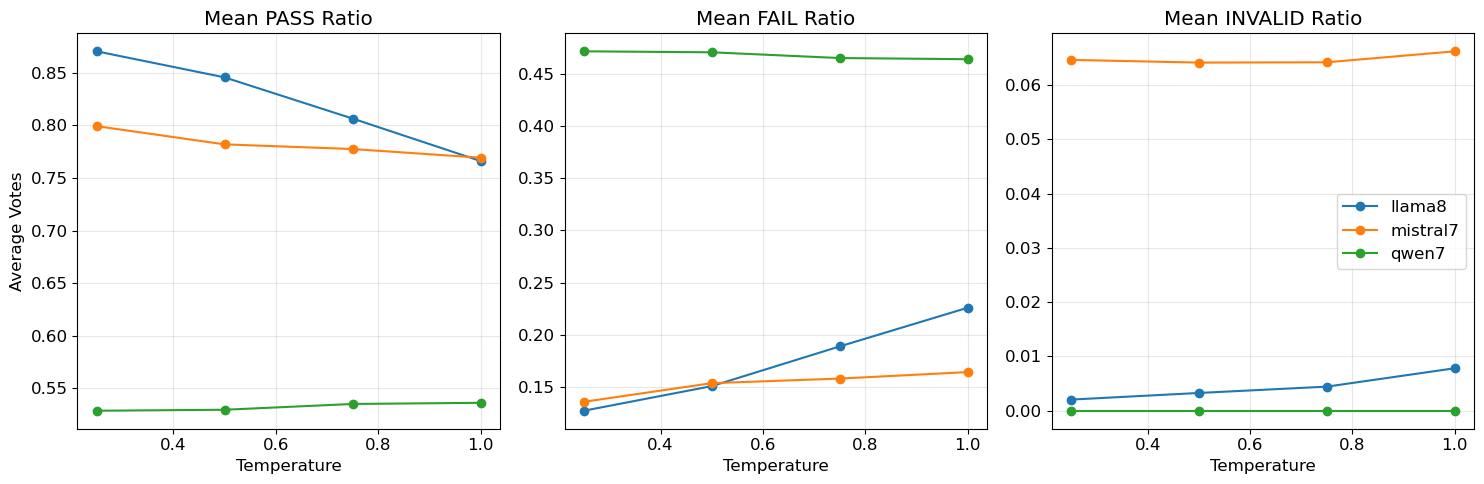

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5),
    sharex=True
)

metrics = [
    "pass_ratio",
    "fail_ratio",
    "invalid_ratio"
]

titles = [
    "Mean PASS Ratio",
    "Mean FAIL Ratio",
    "Mean INVALID Ratio"
]

for ax, metric, title in zip(axes, metrics, titles):

    for judge in majority_summary["judge_model"].unique():

        df_plot = (
            majority_summary[
                majority_summary["judge_model"] == judge
            ]
            .groupby("temperature")[metric]
            .mean()
            .reset_index()
        )

        ax.plot(
            df_plot["temperature"],
            df_plot[metric],
            marker="o",
            label=judge
        )

    ax.set_title(title)
    ax.set_xlabel("Temperature")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Average Votes")
axes[-1].legend()


plt.tight_layout()
plt.savefig(
    "halueval_temperature_votes_ratio_plot.png",
    dpi=300
)
plt.show()

In [23]:
comparison_df = temp_summary.merge(
    majority_summary,
    on=["judge_model", "generator_model", "temperature"],
    how="left"
)

comparison_df[
    [
        "judge_model",
        "generator_model",
        "temperature",
        "mean_accuracy",
        "std_accuracy",
        "majority_accuracy",
        "tie_rate"
    ]
]

,judge_model,generator_model,temperature,mean_accuracy,std_accuracy,majority_accuracy,tie_rate
0,llama8,mistral7,0.25,0.541722,0.005864,0.548000,0.001000
1,llama8,mistral7,0.50,0.539778,0.004214,0.537000,0.003500
2,llama8,mistral7,0.75,0.543556,0.004863,0.546000,0.003000
3,llama8,mistral7,1.00,0.544611,0.007991,0.537000,0.001000
4,mistral7,mistral7,0.25,0.604000,0.003527,0.634000,0.019500
5,mistral7,mistral7,0.50,0.617722,0.004842,0.654000,0.009000
6,mistral7,mistral7,0.75,0.620000,0.006690,0.655000,0.010000
7,mistral7,mistral7,1.00,0.622852,0.007545,0.649941,0.023613
8,qwen7,mistral7,0.25,0.739167,0.004886,0.746000,0.000000
9,qwen7,mistral7,0.50,0.739111,0.003315,0.744000,0.000000


In [24]:
oneshot_plot = (
    results_df[results_df["mode"] == "oneshot"]
    .groupby(
        ["judge_model", "generator_model"]
    )
    .agg(
        single_run_accuracy=("correct", "mean")
    )
    .reset_index()
)

oneshot_plot["temperature"] = 0.0
oneshot_plot["majority_accuracy"] = oneshot_plot["single_run_accuracy"]
oneshot_plot["std_accuracy"] = 0.0

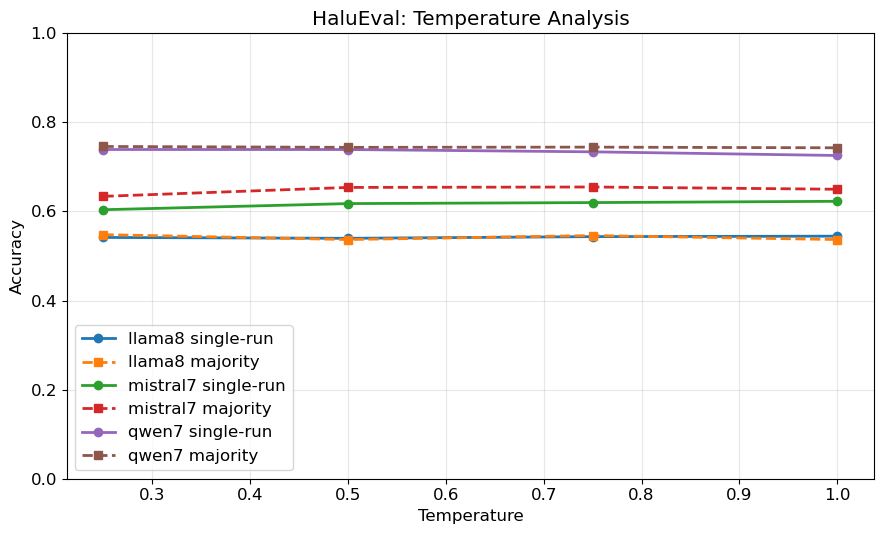

In [25]:
plot_df = temp_summary.merge(
    majority_summary[
        [
            "judge_model",
            "generator_model",
            "temperature",
            "majority_accuracy"
        ]
    ],
    on=[
        "judge_model",
        "generator_model",
        "temperature"
    ],
    how="left"
)

plot_df = plot_df.rename(
    columns={
        "mean_accuracy": "single_run_accuracy"
    }
)

plot_df.head()


plt.figure(figsize=(9, 5.5))

for judge in plot_df["judge_model"].unique():

    temp_df = plot_df[
        plot_df["judge_model"] == judge
    ]

    plt.plot(
        temp_df["temperature"],
        temp_df["single_run_accuracy"],
        marker="o",
        linewidth=2,
        label=f"{judge} single-run"
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_accuracy"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"{judge} majority"
    )

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Temperature Analysis")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_temperature_accuracy_plot.png",
    dpi=300
)

plt.show()

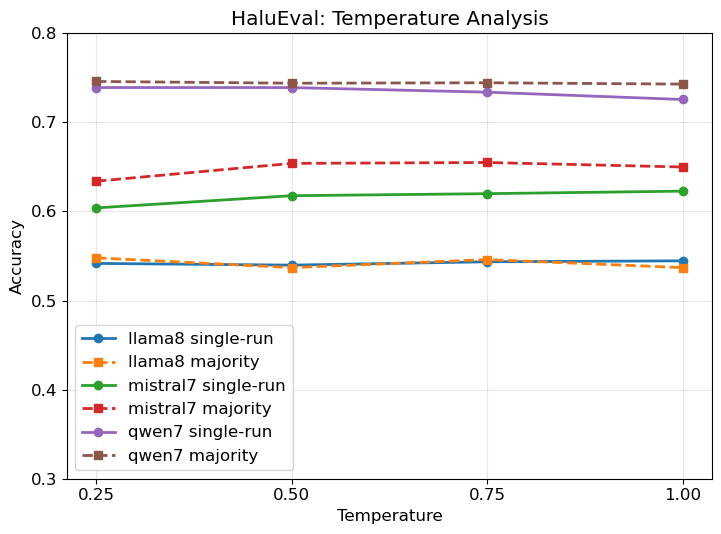

In [26]:
plt.figure(figsize=(9, 5.5))

for judge in plot_df["judge_model"].unique():

    temp_df = (
        plot_df[
            plot_df["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["single_run_accuracy"],
        marker="o",
        linewidth=2,
        label=f"{judge} single-run"
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_accuracy"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"{judge} majority"
    )

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Temperature Analysis")

# Zoom
plt.ylim(0.3, 0.8)

# Δείξε μόνο τα πραγματικά temperatures
plt.xticks(sorted(plot_df["temperature"].unique()))

plt.grid(True, alpha=0.3)

plt.legend(
    #bbox_to_anchor=(1.02, 1),
    loc="lower left"
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig(
    "halueval_temperature_accuracy_plot.png",
    dpi=600
)

plt.show()

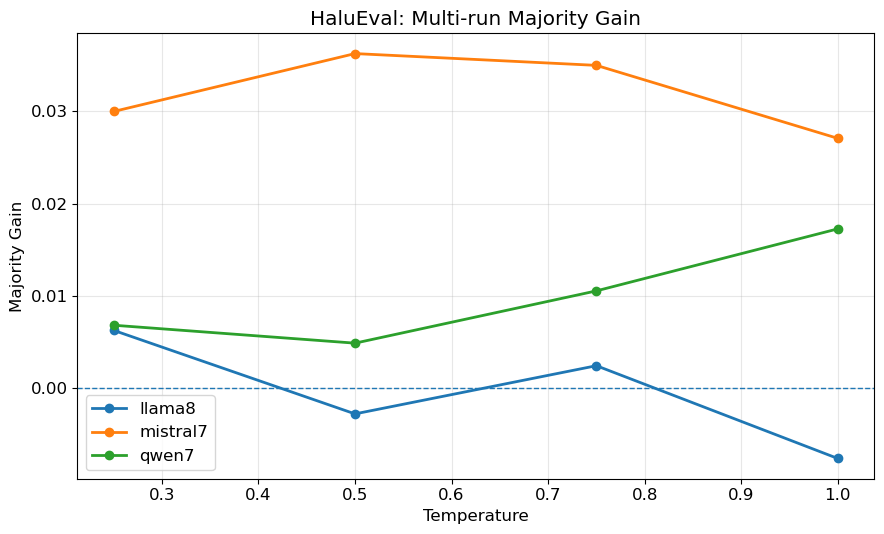

In [27]:
#majoryti gain
plot_df["majority_gain"] = (
    plot_df["majority_accuracy"] -
    plot_df["single_run_accuracy"]
)

plot_df[
    [
        "judge_model",
        "generator_model",
        "temperature",
        "single_run_accuracy",
        "majority_accuracy",
        "majority_gain"
    ]
].round(4)

plt.figure(figsize=(9, 5.5))

for judge in plot_df["judge_model"].unique():

    temp_df = plot_df[
        plot_df["judge_model"] == judge
    ].sort_values("temperature")

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_gain"],
        marker="o",
        linewidth=2,
        label=judge
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Temperature")
plt.ylabel("Majority Gain")
plt.title("HaluEval: Multi-run Majority Gain")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_majority_gain_plot.png",
    dpi=300
)

plt.show()

In [28]:
# ============================================================
# Majority Gain
# ============================================================

plot_df["majority_gain"] = (
    plot_df["majority_accuracy"]
    -
    plot_df["single_run_accuracy"]
)

majority_gain_table = (
    plot_df[
        [
            "judge_model",
            "generator_model",
            "temperature",
            "single_run_accuracy",
            "majority_accuracy",
            "majority_gain"
        ]
    ]
    .sort_values(
        ["judge_model", "temperature"]
    )
    .round(4)
)

majority_gain_table

,judge_model,generator_model,temperature,single_run_accuracy,majority_accuracy,majority_gain
0,llama8,mistral7,0.25,0.5417,0.5480,0.0063
1,llama8,mistral7,0.50,0.5398,0.5370,-0.0028
2,llama8,mistral7,0.75,0.5436,0.5460,0.0024
3,llama8,mistral7,1.00,0.5446,0.5370,-0.0076
4,mistral7,mistral7,0.25,0.6040,0.6340,0.0300
5,mistral7,mistral7,0.50,0.6177,0.6540,0.0363
6,mistral7,mistral7,0.75,0.6200,0.6550,0.0350
7,mistral7,mistral7,1.00,0.6229,0.6499,0.0271
8,qwen7,mistral7,0.25,0.7392,0.7460,0.0068
9,qwen7,mistral7,0.50,0.7391,0.7440,0.0049


In [29]:
plot_df = pd.concat(
    [
        oneshot_plot[
            [
                "judge_model",
                "generator_model",
                "temperature",
                "single_run_accuracy",
                "majority_accuracy",
                "std_accuracy"
            ]
        ],
        plot_df[
            [
                "judge_model",
                "generator_model",
                "temperature",
                "single_run_accuracy",
                "majority_accuracy",
                "std_accuracy"
            ]
        ]
    ],
    ignore_index=True
)

plot_df = plot_df.sort_values(
    ["judge_model", "temperature"]
)

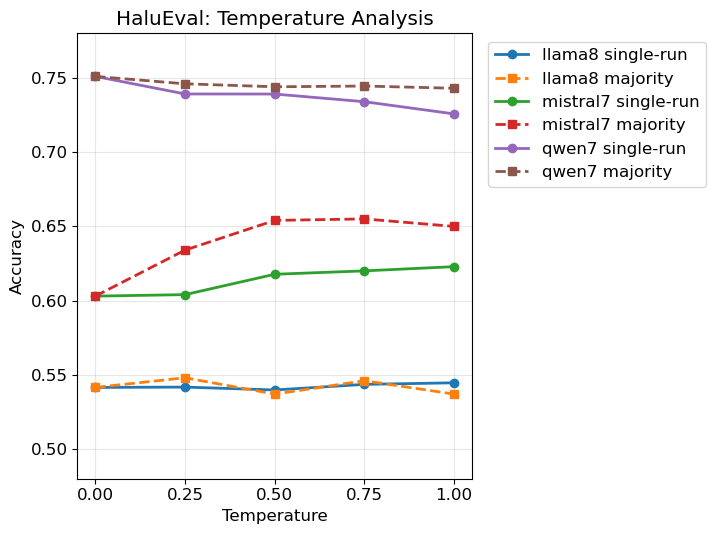

In [31]:
plt.figure(figsize=(9, 5.5))

for judge in plot_df["judge_model"].unique():

    temp_df = (
        plot_df[
            plot_df["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["single_run_accuracy"],
        marker="o",
        linewidth=2,
        label=f"{judge} single-run"
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_accuracy"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"{judge} majority"
    )

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Temperature Analysis")

# Zoom
plt.ylim(0.48, 0.78)

# Δείξε μόνο τα πραγματικά temperatures
plt.xticks(sorted(plot_df["temperature"].unique()))

plt.grid(True, alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig(
    "halueval_temperature_accuracy_plot.png",
    dpi=300
)

plt.show()

## normalization of accuracy 

In [32]:
from pathlib import Path
import json
import pandas as pd
import re

RESULTS_DIR = Path(
    r"C:\Users\georg\Documents\VScode\Thesis\all\old_finalresults\gen_oneshot"
)


def load_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))

    return pd.DataFrame(rows)


all_dfs = []

for f in RESULTS_DIR.glob("*.jsonl"):

    model_name = re.search(
        r"generator_(.*?)_oneshot",
        f.stem.lower()
    ).group(1)

    temp_df = load_jsonl(f)

    temp_df["generator_model"] = model_name

    all_dfs.append(temp_df)

gen_df = pd.concat(
    all_dfs,
    ignore_index=True
)

gen_df.head()

,id,prediction,ground_truth,finish_reason,metadata,run_id,generator_model
0,1,PASS,PASS,stop,"{'prompt_length': '75', 'llama_3_1_bucket': 's...",0,llama8
1,2,PASS,PASS,stop,"{'prompt_length': '149', 'llama_3_1_bucket': '...",0,llama8
2,3,FAIL\n\nThe passage does not provide informati...,PASS,stop,"{'prompt_length': '104', 'llama_3_1_bucket': '...",0,llama8
3,4,FAIL,FAIL,stop,"{'prompt_length': '109', 'llama_3_1_bucket': '...",0,llama8
4,5,PASS,PASS,stop,"{'prompt_length': '121', 'llama_3_1_bucket': '...",0,llama8


In [33]:
gen_df["prediction_norm"] = (
    gen_df["prediction"]
    .apply(normalize_label)
)

gen_df["ground_truth_norm"] = (
    gen_df["ground_truth"]
    .apply(normalize_label)
)

gen_df["correct"] = (
    gen_df["prediction_norm"] ==
    gen_df["ground_truth_norm"]
)

In [34]:
generator_weights = (
    gen_df
    .groupby("generator_model")
    .agg(
        accuracy=("correct", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

generator_weights

,generator_model,accuracy,n
0,llama8,0.8315,2000
1,mistral7,0.7965,2000
2,qwen7,0.8345,2000


In [35]:
weight_dict = (
    generator_weights
    .set_index("generator_model")["accuracy"]
    .to_dict()
)

total = sum(weight_dict.values())

weight_dict = {
    k: v / total
    for k, v in weight_dict.items()
}

weight_dict

{'llama8': 0.3376649746192893,
 'mistral7': 0.3234517766497461,
 'qwen7': 0.3388832487309644}

In [36]:
# Apply in every id-{group} group to get the majority vote for pass/fail/invalid
# ============================================================
# Aggregate multiple runs of each judge into one prediction
# ============================================================

model_temp_predictions = (
    results_df[results_df["mode"] == "multirun"]
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature",
            "id"
        ]
    )["prediction_norm"]
    .apply(majority_vote)
    .reset_index()
)

# Rename for readability in the following analysis
model_temp_predictions = model_temp_predictions.rename(
    columns={
        "majority_prediction": "model_prediction"
    }
)

model_temp_predictions.head()

,judge_model,generator_model,temperature,id,level_4,prediction_norm
0,llama8,mistral7,0.25,1,majority_prediction,pass
1,llama8,mistral7,0.25,1,pass_votes,9
2,llama8,mistral7,0.25,1,fail_votes,0
3,llama8,mistral7,0.25,1,invalid_votes,0
4,llama8,mistral7,0.25,1,tie_votes,0


In [37]:
model_temp_predictions = (
    #results_df[results_df["mode"] == "multirun"]
    results_df[results_df["mode"].isin(["oneshot", "multirun"])]
    .groupby(["judge_model", "generator_model", "temperature", "id"])
    .agg(
        pass_votes=("prediction_norm", lambda x: (x == "pass").sum()),
        fail_votes=("prediction_norm", lambda x: (x == "fail").sum()),
        invalid_votes=("prediction_norm", lambda x: (x == "invalid").sum()),
        total_votes=("prediction_norm", "count"),
        ground_truth_norm=("ground_truth_norm", "first")
    )
    .reset_index()
)

model_temp_predictions["model_prediction"] = model_temp_predictions.apply(
    lambda row: "pass" if row["pass_votes"] > row["fail_votes"]
    else "fail" if row["fail_votes"] > row["pass_votes"]
    else "tie",
    axis=1
)

model_temp_predictions["correct"] = (
    model_temp_predictions["model_prediction"] ==
    model_temp_predictions["ground_truth_norm"]
)

model_temp_predictions.head() #ready and majority per model, temperature, id

,judge_model,generator_model,temperature,id,pass_votes,fail_votes,invalid_votes,total_votes,ground_truth_norm,model_prediction,correct
0,llama8,mistral7,0.0,1,1,0,0,1,pass,pass,True
1,llama8,mistral7,0.0,10,1,0,0,1,pass,pass,True
2,llama8,mistral7,0.0,100,1,0,0,1,pass,pass,True
3,llama8,mistral7,0.0,1000,1,0,0,1,fail,pass,False
4,llama8,mistral7,0.0,1001,1,0,0,1,pass,pass,True


In [38]:
judge_votes = (
    model_temp_predictions
    .pivot_table(
        index=["temperature", "id", "ground_truth_norm"],
        columns="judge_model",
        values="model_prediction",
        aggfunc="first"
    )
    .reset_index()
)

judge_votes.head()
# can be a total majoryty per model, for every temperature, id 

judge_model,temperature,id,ground_truth_norm,llama8,mistral7,qwen7
0,0.0,1,pass,pass,pass,fail
1,0.0,10,pass,pass,pass,fail
2,0.0,100,pass,pass,pass,pass
3,0.0,1000,fail,pass,fail,fail
4,0.0,1001,pass,pass,pass,pass


In [39]:
# Majority in votes of each judge and then across judges
def majority_across_judges(row):

    pass_votes = 0
    fail_votes = 0

    for model in ["llama8", "mistral7", "qwen7"]:

        vote = row.get(model)

        if vote == "pass":
            pass_votes += 1

        elif vote == "fail":
            fail_votes += 1

        # tie / invalid / NaN do not vote

    if pass_votes > fail_votes:
        return "pass"

    elif fail_votes > pass_votes:
        return "fail"

    else:
        return "tie"


judge_votes["ensemble_majority_prediction"] = judge_votes.apply(
    majority_across_judges,
    axis=1
)

judge_votes["ensemble_majority_correct"] = (
    judge_votes["ensemble_majority_prediction"] ==
    judge_votes["ground_truth_norm"]
)

judge_votes.head()

judge_model,temperature,id,ground_truth_norm,llama8,mistral7,qwen7,ensemble_majority_prediction,ensemble_majority_correct
0,0.0,1,pass,pass,pass,fail,pass,True
1,0.0,10,pass,pass,pass,fail,pass,True
2,0.0,100,pass,pass,pass,pass,pass,True
3,0.0,1000,fail,pass,fail,fail,fail,True
4,0.0,1001,pass,pass,pass,pass,pass,True


In [40]:
judge_votes_complete = judge_votes.dropna(
    subset=["llama8", "mistral7", "qwen7"]
).copy()

#keep complete rows where all judges have voted (no NaN values) for further analysis

In [44]:
judge_votes_complete["ensemble_majority_prediction"] = judge_votes_complete.apply(
    majority_across_judges,
    axis=1
)

judge_votes_complete["ensemble_majority_correct"] = (
    judge_votes_complete["ensemble_majority_prediction"] ==
    judge_votes_complete["ground_truth_norm"]
)
# Calculate the accuracy of the ensemble majority prediction

In [45]:
ensemble_majority_summary_complete = (
    judge_votes_complete
    .groupby("temperature")
    .agg(
        ensemble_majority_accuracy=("ensemble_majority_correct", "mean"),
        tie_rate=("ensemble_majority_prediction", lambda x: (x == "tie").mean()),
        n=("id", "count")
    )
    .reset_index()
)

ensemble_majority_summary_complete

,temperature,ensemble_majority_accuracy,tie_rate,n
0,0.00,0.628000,0.04900,2000
1,0.25,0.648500,0.01350,2000
2,0.50,0.650500,0.00950,2000
3,0.75,0.668000,0.00800,2000
4,1.00,0.660567,0.01771,1694


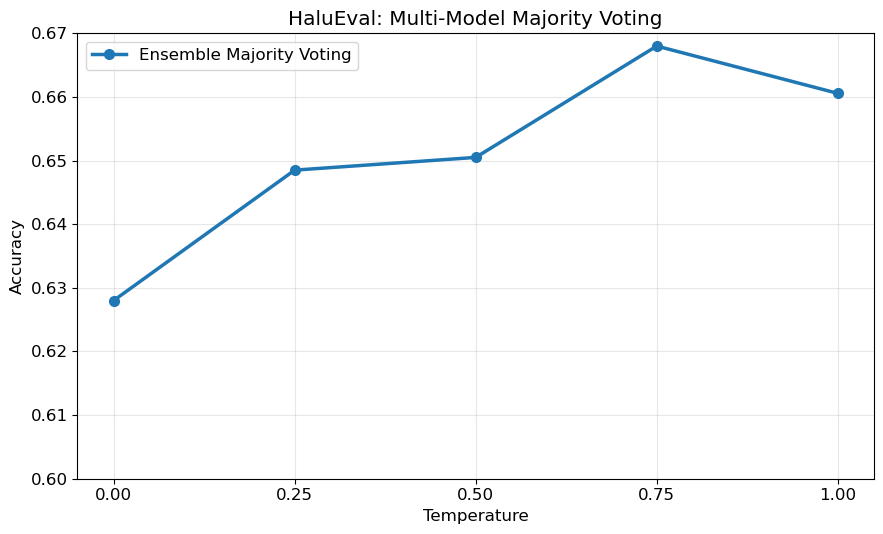

In [46]:
plt.figure(figsize=(9, 5.5))

plt.plot(
    ensemble_majority_summary_complete["temperature"],
    ensemble_majority_summary_complete["ensemble_majority_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Ensemble Majority Voting"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Multi-Model Majority Voting")

plt.xticks(
    ensemble_majority_summary_complete["temperature"]
)

plt.ylim(0.60, 0.67)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "halueval_ensemble_majority_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# ============================================================
# Weighted majority voting across available judges
# Uses all samples, even when mistral7 is missing
# ============================================================

weights = {
    "llama8": 0.337,
    "mistral7": 0.323,
    "qwen7": 0.338
}

def weighted_vote_available(row):
    pass_score = 0.0
    fail_score = 0.0
    invalid_votes = 0
    missing_votes = 0
    used_models = 0

    for model, weight in weights.items():

        vote = row.get(model)

        if pd.isna(vote):
            missing_votes += 1
            continue

        if vote == "pass":
            pass_score += weight
            used_models += 1

        elif vote == "fail":
            fail_score += weight
            used_models += 1

        elif vote in ["invalid", "tie"]:
            invalid_votes += 1

    if pass_score > fail_score:
        pred = "pass"
    elif fail_score > pass_score:
        pred = "fail"
    else:
        pred = "tie"

    return pd.Series({
        "weighted_prediction": pred,
        "pass_score": pass_score,
        "fail_score": fail_score,
        "invalid_votes": invalid_votes,
        "missing_votes": missing_votes,
        "used_models": used_models
    })

weighted_results = judge_votes_complete.apply(
    weighted_vote_available,
    axis=1
)

judge_votes_weighted = pd.concat(
    [judge_votes_complete, weighted_results],
    axis=1
)

judge_votes_weighted["weighted_correct"] = (
    judge_votes_weighted["weighted_prediction"]
    ==
    judge_votes_weighted["ground_truth_norm"]
)

weighted_summary = (
    judge_votes_weighted
    .groupby("temperature")
    .agg(
        weighted_accuracy=("weighted_correct", "mean"),
        weighted_tie_rate=("weighted_prediction", lambda x: (x == "tie").mean()),
        mean_used_models=("used_models", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

weighted_summary

,temperature,weighted_accuracy,weighted_tie_rate,mean_used_models,n
0,0.00,0.676500,0.0,2.936500,2000
1,0.25,0.661500,0.0,2.979500,2000
2,0.50,0.659000,0.0,2.987500,2000
3,0.75,0.675500,0.0,2.987000,2000
4,1.00,0.678276,0.0,2.975797,1694


In [48]:
model_temp_predictions["correct"] = (
    model_temp_predictions["model_prediction"] ==
    model_temp_predictions["ground_truth_norm"]
)

simple_accuracy_summary = (
    model_temp_predictions
    .groupby(
        [
            "judge_model",
            "generator_model",
            "temperature"
        ],
        as_index=False
    )
    .agg(
        simple_accuracy=("correct", "mean"),
        n_simple=("id", "count")
    )
)

simple_accuracy_summary

,judge_model,generator_model,temperature,simple_accuracy,n_simple
0,llama8,mistral7,0.00,0.541500,2000
1,llama8,mistral7,0.25,0.548000,2000
2,llama8,mistral7,0.50,0.537000,2000
3,llama8,mistral7,0.75,0.546000,2000
4,llama8,mistral7,1.00,0.537000,2000
5,mistral7,mistral7,0.00,0.603000,2000
6,mistral7,mistral7,0.25,0.634000,2000
7,mistral7,mistral7,0.50,0.654000,2000
8,mistral7,mistral7,0.75,0.655000,2000
9,mistral7,mistral7,1.00,0.649941,1694


In [49]:
simple_accuracy_by_temp = (
    simple_accuracy_summary
    .groupby(
        "temperature",
        as_index=False
    )
    .agg(
        simple_accuracy=("simple_accuracy", "mean")
    )
)

simple_accuracy_by_temp

,temperature,simple_accuracy
0,0.00,0.631833
1,0.25,0.642667
2,0.50,0.645000
3,0.75,0.648500
4,1.00,0.643314


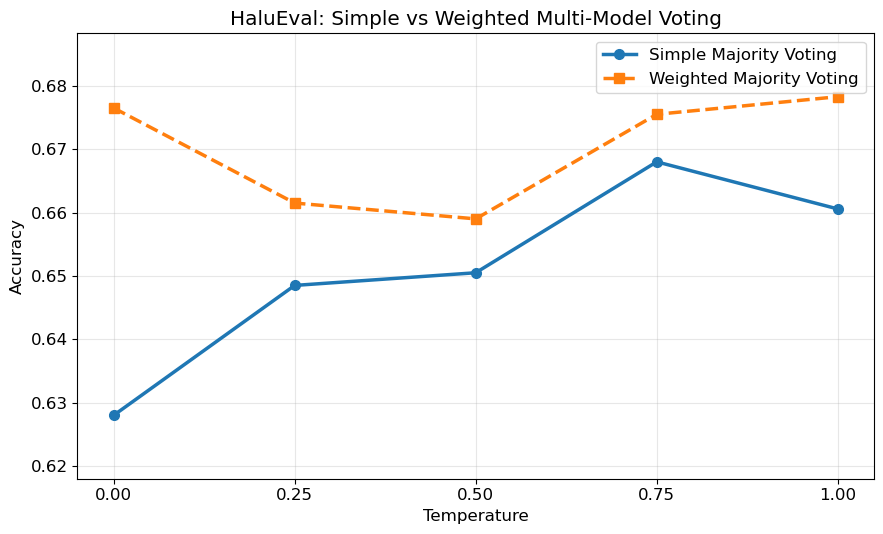

In [50]:
# ============================================================
# Plot simple majority vs weighted majority
# ============================================================


plot_weighted_df = ensemble_majority_summary_complete.merge(
    weighted_summary,
    on="temperature",
    how="left",
    suffixes=("_simple", "_weighted")
)



plt.figure(figsize=(9, 5.5))

plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["ensemble_majority_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Simple Majority Voting"
)

plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["weighted_accuracy"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Weighted Majority Voting"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Simple vs Weighted Multi-Model Voting")
plt.xticks(sorted(plot_weighted_df["temperature"].unique()))

ymin = min(
    plot_weighted_df["ensemble_majority_accuracy"].min(),
    plot_weighted_df["weighted_accuracy"].min()
)

ymax = max(
    plot_weighted_df["ensemble_majority_accuracy"].max(),
    plot_weighted_df["weighted_accuracy"].max()
)

plt.ylim(ymin - 0.01, ymax + 0.01)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_simple_vs_weighted_majority.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

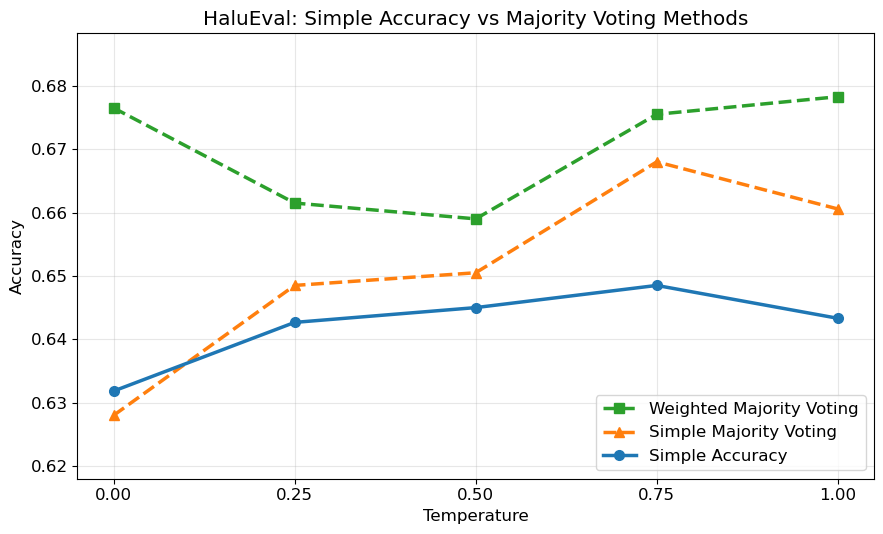

In [51]:
# ============================================================
# Plot simple accuracy vs simple majority vs weighted majority
# ============================================================

plot_weighted_df = (
    ensemble_majority_summary_complete
    .merge(
        weighted_summary,
        on="temperature",
        how="left",
        suffixes=("_simple", "_weighted")
    )
    .merge(
        simple_accuracy_by_temp[
            ["temperature", "simple_accuracy"]
        ],
        on="temperature",
        how="left"
    )
    .sort_values("temperature")
)

plt.figure(figsize=(9, 5.5))

# Weighted Majority Voting (green dashed)
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["weighted_accuracy"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    color="tab:green",
    label="Weighted Majority Voting"
)

# Simple Majority Voting (orange)
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["ensemble_majority_accuracy"],
    marker="^",
    linewidth=2.5,
    linestyle="--",
    markersize=7,
    color="tab:orange",
    label="Simple Majority Voting"
)

# Simple Accuracy (blue)
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["simple_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="tab:blue",
    label="Simple Accuracy"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Simple Accuracy vs Majority Voting Methods")

plt.xticks(sorted(plot_weighted_df["temperature"].unique()))

ymin = min(
    plot_weighted_df["weighted_accuracy"].min(),
    plot_weighted_df["ensemble_majority_accuracy"].min(),
    plot_weighted_df["simple_accuracy"].min()
)

ymax = max(
    plot_weighted_df["weighted_accuracy"].max(),
    plot_weighted_df["ensemble_majority_accuracy"].max(),
    plot_weighted_df["simple_accuracy"].max()
)

plt.ylim(ymin - 0.01, ymax + 0.01)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_simple_accuracy_vs_majority_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

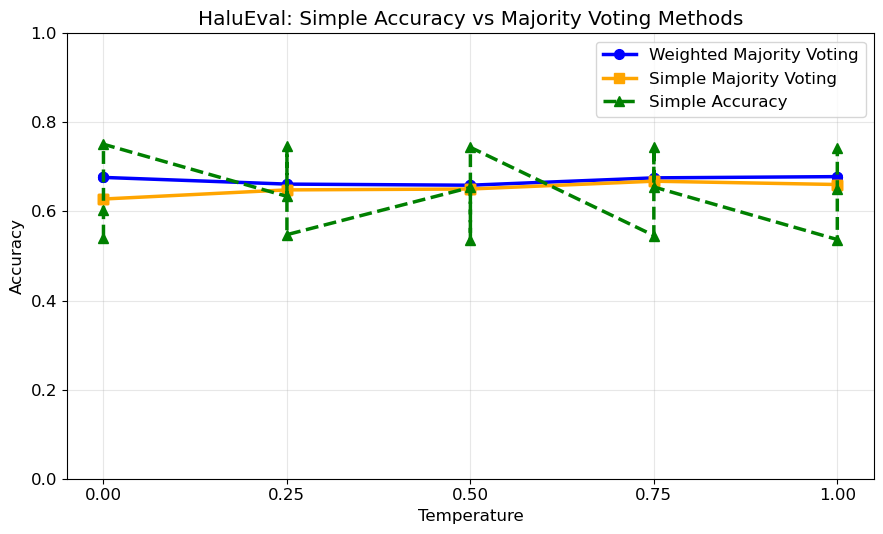

In [52]:
# ============================================================
# Plot: Simple Accuracy vs Simple Majority vs Weighted Majority
# Weighted = blue
# Simple majority = orange
# Simple accuracy = green dashed
# ============================================================

import matplotlib.pyplot as plt

plot_weighted_df = (
    simple_accuracy_summary[
        ["temperature", "simple_accuracy"]
    ]
    .merge(
        ensemble_majority_summary_complete[
            ["temperature", "ensemble_majority_accuracy"]
        ],
        on="temperature",
        how="inner"
    )
    .merge(
        weighted_summary[
            ["temperature", "weighted_accuracy"]
        ],
        on="temperature",
        how="inner"
    )
    .sort_values("temperature")
)

plt.figure(figsize=(9, 5.5))

# Weighted Majority Voting - blue
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["weighted_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="blue",
    label="Weighted Majority Voting"
)

# Simple Majority Voting - orange
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["ensemble_majority_accuracy"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="orange",
    label="Simple Majority Voting"
)

# Simple Accuracy - green dashed
plt.plot(
    plot_weighted_df["temperature"],
    plot_weighted_df["simple_accuracy"],
    marker="^",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    color="green",
    label="Simple Accuracy"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Simple Accuracy vs Majority Voting Methods")

plt.xticks(sorted(plot_weighted_df["temperature"].unique()))
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "halueval_simple_weighted_majority_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
# ============================================================
# Aggregation Gain Table
# Weighted Majority vs Simple Majority
# ============================================================

plot_weighted_df = ensemble_majority_summary_complete.merge(
    weighted_summary,
    on="temperature",
    how="left",
    suffixes=("_simple", "_weighted")
)

aggregation_gain_table = plot_weighted_df.copy()

aggregation_gain_table["aggregation_gain"] = (
    aggregation_gain_table["weighted_accuracy"]
    -
    aggregation_gain_table["ensemble_majority_accuracy"]
)

aggregation_gain_table = aggregation_gain_table[
    [
        "temperature",
        "ensemble_majority_accuracy",
        "weighted_accuracy",
        "aggregation_gain",
        "n_simple",
        "n_weighted"
    ]
].rename(
    columns={
        "ensemble_majority_accuracy": "simple_majority_accuracy",
        "weighted_accuracy": "weighted_majority_accuracy"
    }
)

aggregation_gain_table = aggregation_gain_table.round(4)

display(aggregation_gain_table)

,temperature,simple_majority_accuracy,weighted_majority_accuracy,aggregation_gain,n_simple,n_weighted
0,0.00,0.6280,0.6765,0.0485,2000,2000
1,0.25,0.6485,0.6615,0.0130,2000,2000
2,0.50,0.6505,0.6590,0.0085,2000,2000
3,0.75,0.6680,0.6755,0.0075,2000,2000
4,1.00,0.6606,0.6783,0.0177,1694,1694


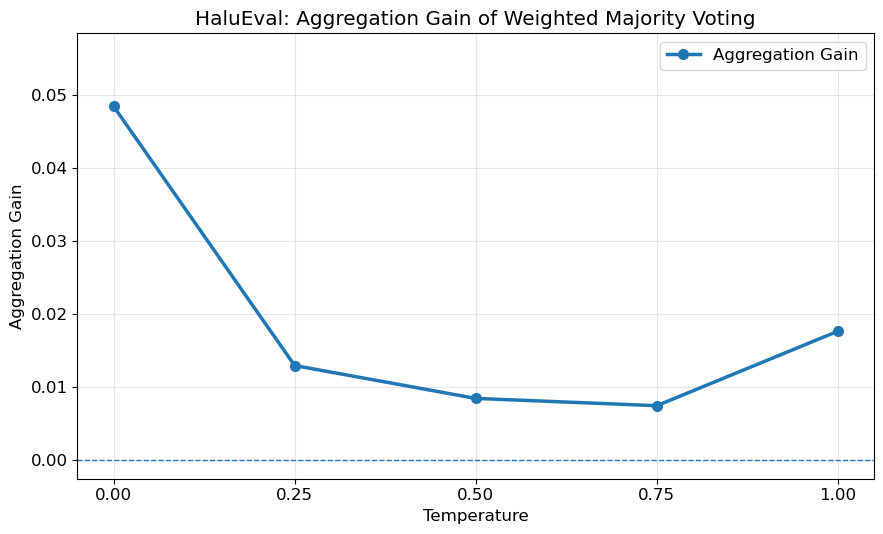

In [54]:
# ============================================================
# Plot Aggregation Gain
# Weighted Majority vs Simple Majority
# ============================================================

plt.figure(figsize=(9, 5.5))

plt.plot(
    aggregation_gain_table["temperature"],
    aggregation_gain_table["aggregation_gain"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Aggregation Gain"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temperature")
plt.ylabel("Aggregation Gain")
plt.title("HaluEval: Aggregation Gain of Weighted Majority Voting")

plt.xticks(aggregation_gain_table["temperature"])

plt.ylim(
    aggregation_gain_table["aggregation_gain"].min() - 0.01,
    aggregation_gain_table["aggregation_gain"].max() + 0.01
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_aggregation_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
# ============================================================
# Diagnostic: Why does weighted majority improve over simple majority?
# ============================================================

# The apparent performance gain of weighted majority voting at temperature 
# 0 does not arise from a general superiority of weighted aggregation. Instead,
# it is almost entirely explained by a recurring disagreement pattern (PASS, TIE, FAIL),
# which appeared 96 times in the evaluation set. In all these cases, the Qwen judge
# matched the ground-truth label, while Llama predicted the opposite label and Mistral 
# abstained (TIE). Since Qwen was assigned the highest reliability weight (0.338 vs. 0.337 for Llama),
# weighted voting consistently resolved these disagreements in the correct direction. Therefore, 
# the observed improvement reflects the interaction between the learned reliability weights and the 
# empirical distribution of disagreement patterns in the dataset, rather than an inherent advantage of 
# weighted voting itself.


# 1. Build comparison table
comparison = (
    judge_votes_complete[
        [
            "temperature",
            "id",
            "ground_truth_norm",
            "ensemble_majority_prediction",
            "ensemble_majority_correct",
            "llama8",
            "mistral7",
            "qwen7"
        ]
    ]
    .merge(
        judge_votes_weighted[
            [
                "temperature",
                "id",
                "weighted_prediction",
                "weighted_correct"
            ]
        ],
        on=["temperature", "id"],
        how="inner"
    )
)

# 2. Classify cases
comparison["case"] = "same"

comparison.loc[
    (~comparison["ensemble_majority_correct"]) &
    (comparison["weighted_correct"]),
    "case"
] = "improved"

comparison.loc[
    (comparison["ensemble_majority_correct"]) &
    (~comparison["weighted_correct"]),
    "case"
] = "worsened"

# 3. Count improved / worsened / same cases
case_summary = (
    comparison
    .groupby(["temperature", "case"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(case_summary)

# 4. Show which voting patterns explain the improvements
improvement_patterns = (
    comparison[
        comparison["case"] == "improved"
    ][
        [
            "temperature",
            "llama8",
            "mistral7",
            "qwen7",
            "ground_truth_norm",
            "ensemble_majority_prediction",
            "weighted_prediction"
        ]
    ]
    .value_counts()
    .reset_index(name="count")
)

display(improvement_patterns)

# 5. Focus on the dominant pattern:
# llama8 = pass, mistral7 = tie, qwen7 = fail
dominant_pattern = comparison[
    (comparison["llama8"] == "pass") &
    (comparison["mistral7"] == "tie") &
    (comparison["qwen7"] == "fail")
].copy()

dominant_pattern_summary = (
    dominant_pattern
    .groupby("temperature")
    .agg(
        n=("id", "count"),
        gt_fail_rate=("ground_truth_norm", lambda x: (x == "fail").mean()),
        simple_tie_rate=("ensemble_majority_prediction", lambda x: (x == "tie").mean()),
        weighted_fail_rate=("weighted_prediction", lambda x: (x == "fail").mean()),
        weighted_correct_rate=("weighted_correct", "mean")
    )
    .reset_index()
)

display(dominant_pattern_summary)

# 6. Check which judge is correct in the improved cases at T=0
improved_t0 = comparison[
    (comparison["temperature"] == 0.0) &
    (comparison["case"] == "improved")
].copy()

for judge in ["llama8", "mistral7", "qwen7"]:
    improved_t0[f"{judge}_correct"] = (
        improved_t0[judge] == improved_t0["ground_truth_norm"]
    )

judge_correct_in_improved_t0 = improved_t0[
    [
        "llama8_correct",
        "mistral7_correct",
        "qwen7_correct"
    ]
].mean()

display(judge_correct_in_improved_t0)

case,temperature,improved,same
0,0.00,97,1903
1,0.25,26,1974
2,0.50,17,1983
3,0.75,15,1985
4,1.00,30,1664


,temperature,llama8,mistral7,qwen7,ground_truth_norm,ensemble_majority_prediction,weighted_prediction,count
0,0.00,pass,tie,fail,fail,tie,fail,96
1,1.00,pass,tie,fail,fail,tie,fail,30
2,0.25,pass,tie,fail,fail,tie,fail,26
3,0.50,pass,tie,fail,fail,tie,fail,17
4,0.75,pass,tie,fail,fail,tie,fail,15
5,0.00,tie,pass,fail,fail,tie,fail,1


,temperature,n,gt_fail_rate,simple_tie_rate,weighted_fail_rate,weighted_correct_rate
0,0.00,96,1.0,1.0,1.0,1.0
1,0.25,26,1.0,1.0,1.0,1.0
2,0.50,17,1.0,1.0,1.0,1.0
3,0.75,15,1.0,1.0,1.0,1.0
4,1.00,30,1.0,1.0,1.0,1.0


llama8_correct      0.0
mistral7_correct    0.0
qwen7_correct       1.0
dtype: float64

In [56]:
# simple_accuracy_summary = (
#     model_temp_predictions
#     .groupby("temperature")
#     .agg(
#         simple_accuracy=("correct", "mean"),
#         n=("id", "count")
#     )
#     .reset_index()
# )

# simple_accuracy_summary

In [57]:
weights = {
    "llama8": 0.337,
    "mistral7": 0.323,
    "qwen7": 0.338
}

weighted_accuracy_df = model_temp_predictions.copy()

weighted_accuracy_df["weight"] = (
    weighted_accuracy_df["judge_model"]
    .map(weights)
)

weighted_accuracy_df["weighted_correct"] = (
    weighted_accuracy_df["correct"].astype(float)
    *
    weighted_accuracy_df["weight"]
)
weighted_accuracy_summary = (
    weighted_accuracy_df
    .groupby("temperature")
    .apply(
        lambda g: pd.Series({
            "weighted_accuracy": g["weighted_correct"].sum() / g["weight"].sum(),
            "n": len(g)
        })
    )
    .reset_index()
)

weighted_accuracy_summary

C:\Users\georg\AppData\Local\Temp\ipykernel_22440\625417767.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,temperature,weighted_accuracy,n
0,0.00,0.632357,6000.0
1,0.25,0.642892,6000.0
2,0.50,0.644973,6000.0
3,0.75,0.648505,6000.0
4,1.00,0.642976,5694.0


In [58]:
accuracy_comparison_summary = simple_accuracy_summary.merge(
    weighted_accuracy_summary,
    on=["temperature", "n"],
    how="left"
)

accuracy_comparison_summary

KeyError: 'n'

In [59]:
# ============================================================
# Simple Accuracy vs Weighted Accuracy
# ============================================================

plot_df = simple_accuracy_summary.merge(
    weighted_accuracy_summary,
    on=["temperature", "n"],
    how="inner"
)

plt.figure(figsize=(9, 5.5))

plt.plot(
    plot_df["temperature"],
    plot_df["simple_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Simple Accuracy"
)

plt.plot(
    plot_df["temperature"],
    plot_df["weighted_accuracy"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Weighted Accuracy"
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy")
plt.title("HaluEval: Judge Accuracy Across Temperatures")

plt.xticks(
    sorted(plot_df["temperature"].unique())
)

ymin = min(
    plot_df["simple_accuracy"].min(),
    plot_df["weighted_accuracy"].min()
)

ymax = max(
    plot_df["simple_accuracy"].max(),
    plot_df["weighted_accuracy"].max()
)

plt.ylim(ymin - 0.01, ymax + 0.01)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_simple_vs_weighted_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

KeyError: 'n'

## metrics

In [60]:
# ============================================================
# Internal metric 1: Disagreement / Consistency across runs
# ============================================================

stability_df = (
    results_df[results_df["mode"] == "multirun"]
    .groupby(["judge_model", "generator_model", "temperature", "id"])
    .agg(
        unique_predictions=("prediction_norm", lambda x: x.nunique()),
        total_runs=("prediction_norm", "count")
    )
    .reset_index()
)

stability_df["has_disagreement"] = (
    stability_df["unique_predictions"] > 1
)

stability_summary = (
    stability_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        disagreement_rate=("has_disagreement", "mean"),
        consistency_rate=("has_disagreement", lambda x: 1 - x.mean()),
        avg_unique_predictions=("unique_predictions", "mean"),
        n=("id", "count")
    )
    .reset_index()
)

stability_summary

,judge_model,generator_model,temperature,disagreement_rate,consistency_rate,avg_unique_predictions,n
0,llama8,mistral7,0.25,0.142000,0.858000,1.147500,2000
1,llama8,mistral7,0.50,0.293000,0.707000,1.300500,2000
2,llama8,mistral7,0.75,0.476000,0.524000,1.494000,2000
3,llama8,mistral7,1.00,0.666500,0.333500,1.694500,2000
4,mistral7,mistral7,0.25,0.176500,0.823500,1.204500,2000
5,mistral7,mistral7,0.50,0.235000,0.765000,1.294000,2000
6,mistral7,mistral7,0.75,0.276000,0.724000,1.373000,2000
7,mistral7,mistral7,1.00,0.318182,0.681818,1.456907,1694
8,qwen7,mistral7,0.25,0.149000,0.851000,1.149000,2000
9,qwen7,mistral7,0.50,0.146500,0.853500,1.146500,2000


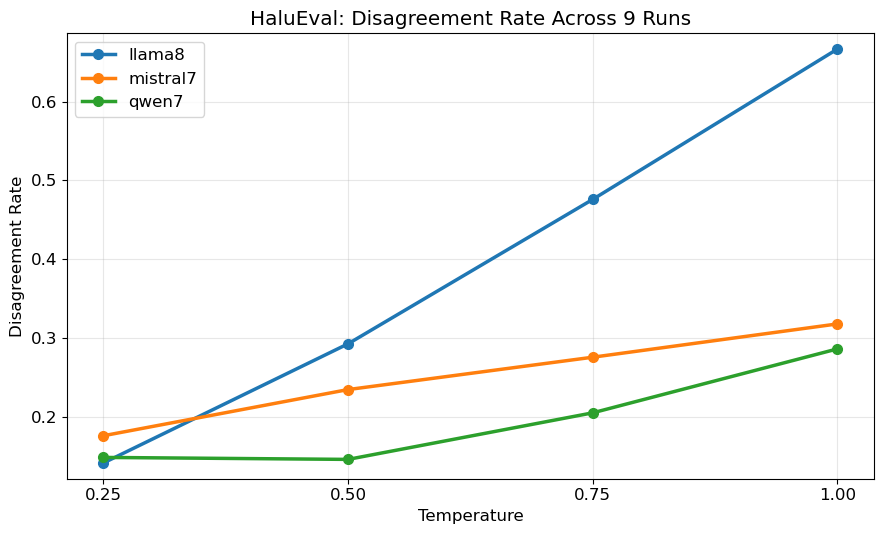

In [61]:
# ============================================================
# Plot: Disagreement rate across 9 runs
# ============================================================

plt.figure(figsize=(9, 5.5))

for judge in stability_summary["judge_model"].unique():

    temp_df = (
        stability_summary[
            stability_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["disagreement_rate"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=judge
    )

plt.xlabel("Temperature")
plt.ylabel("Disagreement Rate")
plt.title("HaluEval: Disagreement Rate Across 9 Runs")

plt.xticks(sorted(stability_summary["temperature"].unique()))

plt.ylim(
    stability_summary["disagreement_rate"].min() - 0.02,
    stability_summary["disagreement_rate"].max() + 0.02
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_disagreement_rate_9_runs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

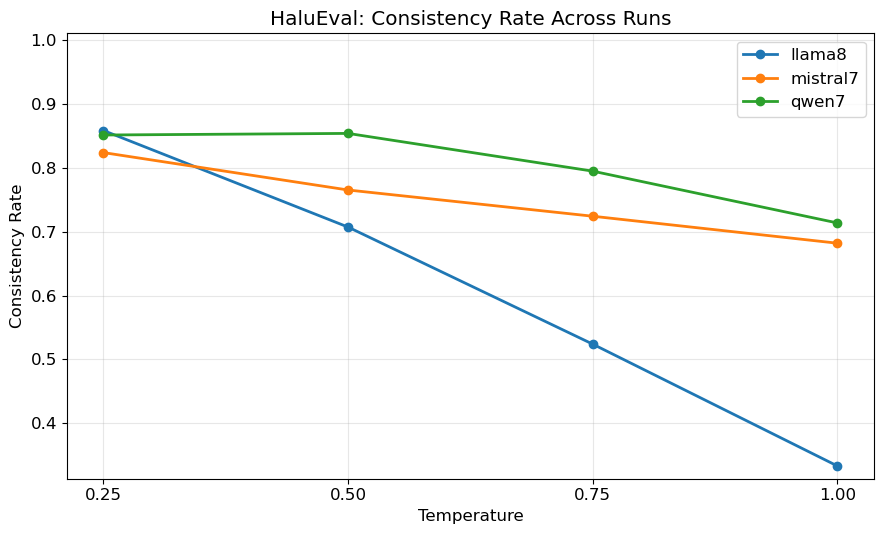

In [62]:
plt.figure(figsize=(9, 5.5))

for judge in stability_summary["judge_model"].unique():

    temp_df = (
        stability_summary[
            stability_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        #temp_df["disagreement_rate"],
        temp_df["consistency_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

    
# και άλλαξε y σε:

plt.xlabel("Temperature")
plt.ylabel("Consistency Rate")
plt.title("HaluEval: Consistency Rate Across Runs")

plt.xticks(
    sorted(stability_summary["temperature"].unique())
)

plt.ylim(
    stability_summary["consistency_rate"].min() - 0.02,
    1.01
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_consistency_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
plot_df.columns.tolist()

['judge_model',
 'generator_model',
 'temperature',
 'single_run_accuracy',
 'majority_accuracy',
 'std_accuracy']

In [64]:
# ============================================================
# Internal metric 2: Majority Gain per Judge
# HaluEval: Single-run Accuracy vs Multi-run Majority Accuracy
# ============================================================

# ------------------------------------------------------------
# 1. Single-run accuracy per judge
# ------------------------------------------------------------

single_run_summary = (
    results_df[results_df["mode"] == "multirun"]
    .groupby(["judge_model", "generator_model", "temperature", "run_id"])
    .agg(
        run_accuracy=("correct", "mean"),
        n_run=("id", "count")
    )
    .reset_index()
)

single_run_summary = (
    single_run_summary
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        single_run_accuracy=("run_accuracy", "mean"),
        n_single=("n_run", "sum")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Multi-run majority accuracy per judge
# ------------------------------------------------------------

majority_summary = (
    model_temp_predictions
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        majority_accuracy=("correct", "mean"),
        n_majority=("id", "count")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Add temperature 0.0 oneshot baseline
# ------------------------------------------------------------

oneshot_summary = (
    results_df[results_df["mode"] == "oneshot"]
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        single_run_accuracy=("correct", "mean"),
        majority_accuracy=("correct", "mean"),
        n_single=("id", "count"),
        n_majority=("id", "count")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4. Majority gain per judge
# ------------------------------------------------------------

majority_gain_table = (
    single_run_summary
    .merge(
        majority_summary,
        on=["judge_model", "generator_model", "temperature"],
        how="inner"
    )
)

majority_gain_table = pd.concat(
    [
        oneshot_summary,
        majority_gain_table
    ],
    ignore_index=True
)

majority_gain_table["majority_gain"] = (
    majority_gain_table["majority_accuracy"]
    -
    majority_gain_table["single_run_accuracy"]
)

majority_gain_table = majority_gain_table.sort_values(
    ["judge_model", "temperature"]
)

# ------------------------------------------------------------
# 5. Clean display
# ------------------------------------------------------------

majority_gain_display = majority_gain_table.copy()

for col in [
    "single_run_accuracy",
    "majority_accuracy",
    "majority_gain"
]:
    majority_gain_display[col] = majority_gain_display[col].round(4)

majority_gain_display

,judge_model,generator_model,temperature,single_run_accuracy,majority_accuracy,n_single,n_majority,majority_gain
0,llama8,mistral7,0.00,0.5415,0.5415,2000,2000,0.0000
3,llama8,mistral7,0.25,0.5417,0.5480,18000,2000,0.0063
4,llama8,mistral7,0.50,0.5398,0.5370,18000,2000,-0.0028
5,llama8,mistral7,0.75,0.5436,0.5460,18000,2000,0.0024
6,llama8,mistral7,1.00,0.5446,0.5370,18000,2000,-0.0076
1,mistral7,mistral7,0.00,0.6030,0.6030,2000,2000,0.0000
7,mistral7,mistral7,0.25,0.6040,0.6340,18000,2000,0.0300
8,mistral7,mistral7,0.50,0.6177,0.6540,18000,2000,0.0363
9,mistral7,mistral7,0.75,0.6200,0.6550,18000,2000,0.0350
10,mistral7,mistral7,1.00,0.6229,0.6499,15246,1694,0.0271


\begin{equation}
\mathrm{MajorityGain}
=
Acc_{\mathrm{majority}}
-
Acc_{\mathrm{single}}
\end{equation}

In [65]:
# ============================================================
# HaluEval: Aggregation Gain Across Temperatures
# ============================================================

aggregation_gain_display = accuracy_comparison_summary.copy()

aggregation_gain_display["aggregation_gain"] = (
    aggregation_gain_display["weighted_accuracy"]
    -
    aggregation_gain_display["simple_accuracy"]
)

plt.figure(figsize=(10, 6))

# ------------------------------------------------------------
# Multi-run Majority Gain
# ------------------------------------------------------------

for judge in majority_gain_table["judge_model"].unique():

    temp_df = (
        majority_gain_table[
            majority_gain_table["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["majority_gain"],
        marker="o",
        linewidth=2,
        label=f"{judge} (multi-run)"
    )

# ------------------------------------------------------------
# Weighted Aggregation Gain
# ------------------------------------------------------------

plt.plot(
    accuracy_comparison_summary["temperature"],
    accuracy_comparison_summary["weighted_accuracy"] - accuracy_comparison_summary["simple_accuracy"],
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Weighted Aggregation"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temperature")
plt.ylabel("Accuracy Gain")

plt.title(
    "HaluEval: Aggregation Gain Across Temperatures"
)

plt.xticks(
    sorted(
        accuracy_comparison_summary["temperature"].unique()
    )
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "halueval_aggregation_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'accuracy_comparison_summary' is not defined

In [66]:
# ============================================================
# Internal metric 2: Weighted Majority Gain
# ============================================================

weighted_gain_df = accuracy_comparison_summary.copy()

weighted_gain_df["weighted_majority_gain"] = (
    weighted_gain_df["weighted_accuracy"]
    -
    weighted_gain_df["simple_accuracy"]
)

weighted_gain_table = weighted_gain_df[
    [
        "temperature",
        "simple_accuracy",
        "weighted_accuracy",
        "weighted_majority_gain"
    ]
].copy()

weighted_gain_table = weighted_gain_table.sort_values(
    "temperature"
)

weighted_gain_table

NameError: name 'accuracy_comparison_summary' is not defined

In [67]:
# ============================================================
# False Support / False Rejection
# Uses majority-voted predictions across runs
# ============================================================

interaction_df = model_temp_predictions.copy()

interaction_df["judge_pass"] = (
    interaction_df["model_prediction"] == "pass"
)

interaction_summary = (
    interaction_df
    .groupby(
        [
            "judge_model",
            "temperature"
        ]
    )
    .apply(
        lambda g: pd.Series({

            "false_support_rate":
                (
                    (
                        (g["ground_truth_norm"] == "fail")
                        &
                        (g["judge_pass"])
                    ).sum()
                )
                /
                (
                    (g["ground_truth_norm"] == "fail").sum()
                ),

            "false_rejection_rate":
                (
                    (
                        (g["ground_truth_norm"] == "pass")
                        &
                        (~g["judge_pass"])
                    ).sum()
                )
                /
                (
                    (g["ground_truth_norm"] == "pass").sum()
                ),

            "n":
                len(g)

        })
    )
    .reset_index()
)

interaction_summary.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_22440\3317047738.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,judge_model,temperature,false_support_rate,false_rejection_rate,n
0,llama8,0.00,0.8240,0.0900,2000.0
1,llama8,0.25,0.8290,0.0740,2000.0
2,llama8,0.50,0.8270,0.0930,2000.0
3,llama8,0.75,0.8140,0.0880,2000.0
4,llama8,1.00,0.8090,0.1150,2000.0
5,mistral7,0.00,0.6340,0.0380,2000.0
6,mistral7,0.25,0.6600,0.0340,2000.0
7,mistral7,0.50,0.6390,0.0360,2000.0
8,mistral7,0.75,0.6350,0.0350,2000.0
9,mistral7,1.00,0.6139,0.0413,1694.0


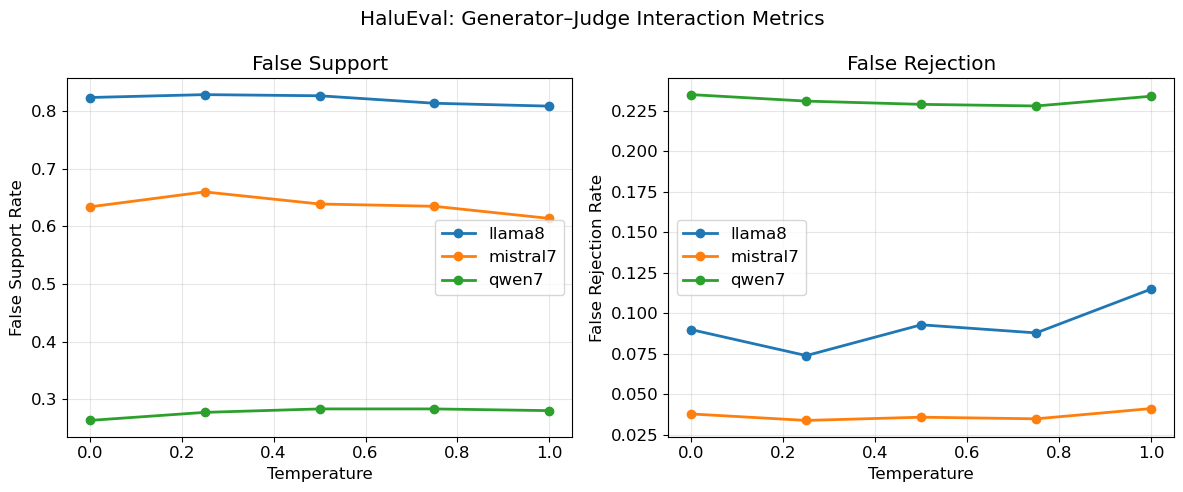

In [68]:
# ============================================================
# False Support & False Rejection
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# False Support
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[0].plot(
        df["temperature"],
        df["false_support_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("False Support Rate")
axes[0].set_title("False Support")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ------------------------------------------------------------
# False Rejection
# ------------------------------------------------------------

for judge in interaction_summary["judge_model"].unique():

    df = (
        interaction_summary[
            interaction_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[1].plot(
        df["temperature"],
        df["false_rejection_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("False Rejection Rate")
axes[1].set_title("False Rejection")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle(
    "HaluEval: Generator–Judge Interaction Metrics"
)

plt.tight_layout()

plt.savefig(
    "halueval_false_support_false_rejection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
interaction_df.groupby(
    ["judge_model", "temperature"]
).apply(
    lambda g: pd.Series({
        "generator_wrong":
            (g["ground_truth_norm"] == "fail").sum(),

        "false_support":
            (
                (g["ground_truth_norm"] == "fail")
                &
                (g["judge_pass"])
            ).sum(),

        "generator_correct":
            (g["ground_truth_norm"] == "pass").sum(),

        "false_rejection":
            (
                (g["ground_truth_norm"] == "pass")
                &
                (~g["judge_pass"])
            ).sum()
    })
).reset_index()

C:\Users\georg\AppData\Local\Temp\ipykernel_22440\2835565220.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


,judge_model,temperature,generator_wrong,false_support,generator_correct,false_rejection
0,llama8,0.00,1000,824,1000,90
1,llama8,0.25,1000,829,1000,74
2,llama8,0.50,1000,827,1000,93
3,llama8,0.75,1000,814,1000,88
4,llama8,1.00,1000,809,1000,115
5,mistral7,0.00,1000,634,1000,38
6,mistral7,0.25,1000,660,1000,34
7,mistral7,0.50,1000,639,1000,36
8,mistral7,0.75,1000,635,1000,35
9,mistral7,1.00,847,520,847,35


For bias and robustnes exp.
To further investigate the behaviour of the judges beyond overall accuracy, the relationship between generator correctness and judge decisions was analyzed through the False Support and False Rejection rates. The results revealed substantial differences among the evaluated models, while the effect of temperature remained relatively limited. Llama8 consistently exhibited the highest False Support rate, accepting approximately 78–82% of incorrect generator outputs, while maintaining comparatively low False Rejection rates. This behaviour suggests a permissive evaluation strategy, where the model tends to favor accepting responses even when they are incorrect. In contrast, Qwen7 demonstrated the opposite tendency, producing the lowest False Support rates (approximately 26–27%) but the highest False Rejection rates (around 23–24%), indicating a significantly stricter evaluation behaviour. Mistral7 occupied an intermediate position, combining moderate False Support rates with consistently low False Rejection rates, resulting in the most balanced judging profile among the evaluated models.

Interestingly, these tendencies remained largely stable across all temperature settings. While minor fluctuations were observed, no substantial changes in False Support or False Rejection rates were detected as temperature increased. This suggests that the evaluation characteristics of each judge are primarily determined by model-specific decision patterns rather than stochastic sampling effects. Consequently, the observed differences appear to reflect inherent evaluation biases of the models, with some judges being systematically more permissive and others more conservative when assessing generator outputs.


The False Support Rate (FSR) measures the tendency of a judge to incorrectly accept responses generated by an incorrect generator output. Formally, it is defined as:

\begin{equation}
\mathrm{FSR}
=
P(J_i = 1 \mid G_i = 0)
=
\frac{
\#(J_i = 1 \land G_i = 0)
}{
\#(G_i = 0)
}
\end{equation}

where $G_i = 0$ indicates that the generator output is incorrect and $J_i = 1$ indicates that the judge assigns a \texttt{PASS} label.

Similarly, the False Rejection Rate (FRR) measures the tendency of a judge to incorrectly reject responses generated by a correct generator output:

\begin{equation}
\mathrm{FRR}
=
P(J_i = 0 \mid G_i = 1)
=
\frac{
\#(J_i = 0 \land G_i = 1)
}{
\#(G_i = 1)
}
\end{equation}

where $G_i = 1$ indicates that the generator output is correct and $J_i = 0$ indicates that the judge assigns a \texttt{FAIL} label.

In [70]:
interaction_counts = (
    interaction_df
    .groupby(["judge_model", "temperature"])
    .apply(
        lambda g: pd.Series({
            "generator_wrong": (g["ground_truth_norm"] == "fail").sum(),
            "false_support": (
                (g["ground_truth_norm"] == "fail") &
                (g["judge_pass"])
            ).sum(),
            "generator_correct": (g["ground_truth_norm"] == "pass").sum(),
            "false_rejection": (
                (g["ground_truth_norm"] == "pass") &
                (~g["judge_pass"])
            ).sum()
        })
    )
    .reset_index()
)

interaction_counts["false_support_rate"] = (
    interaction_counts["false_support"] /
    interaction_counts["generator_wrong"]
)

interaction_counts["false_rejection_rate"] = (
    interaction_counts["false_rejection"] /
    interaction_counts["generator_correct"]
)

interaction_counts.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_22440\2916560776.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,judge_model,temperature,generator_wrong,false_support,generator_correct,false_rejection,false_support_rate,false_rejection_rate
0,llama8,0.00,1000,824,1000,90,0.8240,0.0900
1,llama8,0.25,1000,829,1000,74,0.8290,0.0740
2,llama8,0.50,1000,827,1000,93,0.8270,0.0930
3,llama8,0.75,1000,814,1000,88,0.8140,0.0880
4,llama8,1.00,1000,809,1000,115,0.8090,0.1150
5,mistral7,0.00,1000,634,1000,38,0.6340,0.0380
6,mistral7,0.25,1000,660,1000,34,0.6600,0.0340
7,mistral7,0.50,1000,639,1000,36,0.6390,0.0360
8,mistral7,0.75,1000,635,1000,35,0.6350,0.0350
9,mistral7,1.00,847,520,847,35,0.6139,0.0413


In [71]:
interaction_appendix = interaction_counts.copy()

interaction_appendix[
    ["false_support_rate", "false_rejection_rate"]
] = interaction_appendix[
    ["false_support_rate", "false_rejection_rate"]
].round(4)

interaction_appendix

,judge_model,temperature,generator_wrong,false_support,generator_correct,false_rejection,false_support_rate,false_rejection_rate
0,llama8,0.00,1000,824,1000,90,0.8240,0.0900
1,llama8,0.25,1000,829,1000,74,0.8290,0.0740
2,llama8,0.50,1000,827,1000,93,0.8270,0.0930
3,llama8,0.75,1000,814,1000,88,0.8140,0.0880
4,llama8,1.00,1000,809,1000,115,0.8090,0.1150
5,mistral7,0.00,1000,634,1000,38,0.6340,0.0380
6,mistral7,0.25,1000,660,1000,34,0.6600,0.0340
7,mistral7,0.50,1000,639,1000,36,0.6390,0.0360
8,mistral7,0.75,1000,635,1000,35,0.6350,0.0350
9,mistral7,1.00,847,520,847,35,0.6139,0.0413


In [72]:
std_table = temp_summary[
    [
        "judge_model",
        "temperature",
        "mean_accuracy",
        "std_accuracy"
    ]
].copy()

std_table.round(4)

,judge_model,temperature,mean_accuracy,std_accuracy
0,llama8,0.25,0.5417,0.0059
1,llama8,0.50,0.5398,0.0042
2,llama8,0.75,0.5436,0.0049
3,llama8,1.00,0.5446,0.0080
4,mistral7,0.25,0.6040,0.0035
5,mistral7,0.50,0.6177,0.0048
6,mistral7,0.75,0.6200,0.0067
7,mistral7,1.00,0.6229,0.0075
8,qwen7,0.25,0.7392,0.0049
9,qwen7,0.50,0.7391,0.0033


In [73]:
# ============================================================
# Invalid Rate across majority-voted predictions
# ============================================================

invalid_summary = (
    majority_df
    .groupby(["judge_model", "generator_model", "temperature"])
    .agg(
        invalid_rate=(
            "majority_prediction",
            lambda x: (~x.isin(["pass", "fail"])).mean()
        ),
        n=("id", "count")
    )
    .reset_index()
)

invalid_summary

,judge_model,generator_model,temperature,invalid_rate,n
0,llama8,mistral7,0.25,0.001000,2000
1,llama8,mistral7,0.50,0.003500,2000
2,llama8,mistral7,0.75,0.003000,2000
3,llama8,mistral7,1.00,0.001000,2000
4,mistral7,mistral7,0.25,0.019500,2000
5,mistral7,mistral7,0.50,0.009000,2000
6,mistral7,mistral7,0.75,0.010000,2000
7,mistral7,mistral7,1.00,0.023613,1694
8,qwen7,mistral7,0.25,0.000000,2000
9,qwen7,mistral7,0.50,0.000000,2000


In [74]:
interaction_summary_with_invalid = (
    interaction_summary
    .merge(
        invalid_summary[
            [
                "judge_model",
                #"generator_model",
                "temperature",
                "invalid_rate"
            ]
        ],
        on=[
            "judge_model",
            #"generator_model",
            "temperature"
        ],
        how="left"
    )
)

interaction_summary_with_invalid.round(4)

,judge_model,temperature,false_support_rate,false_rejection_rate,n,invalid_rate
0,llama8,0.00,0.8240,0.0900,2000.0,NaN
1,llama8,0.25,0.8290,0.0740,2000.0,0.0010
2,llama8,0.50,0.8270,0.0930,2000.0,0.0035
3,llama8,0.75,0.8140,0.0880,2000.0,0.0030
4,llama8,1.00,0.8090,0.1150,2000.0,0.0010
5,mistral7,0.00,0.6340,0.0380,2000.0,NaN
6,mistral7,0.25,0.6600,0.0340,2000.0,0.0195
7,mistral7,0.50,0.6390,0.0360,2000.0,0.0090
8,mistral7,0.75,0.6350,0.0350,2000.0,0.0100
9,mistral7,1.00,0.6139,0.0413,1694.0,0.0236


In [75]:
print(interaction_summary.columns.tolist())
print(invalid_summary.columns.tolist())

['judge_model', 'temperature', 'false_support_rate', 'false_rejection_rate', 'n']
['judge_model', 'generator_model', 'temperature', 'invalid_rate', 'n']


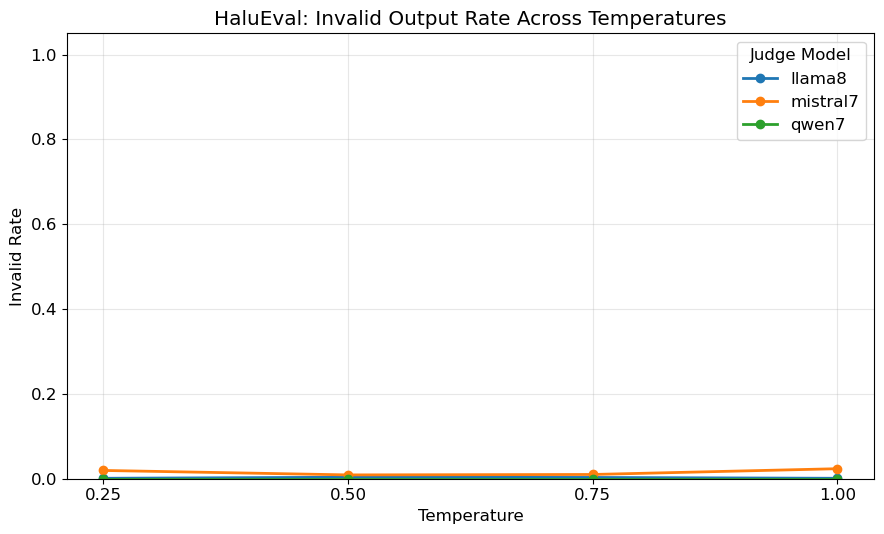

In [76]:
# ============================================================
# Invalid Rate Across Temperatures
# ============================================================

plt.figure(figsize=(9, 5.5))

for judge in invalid_summary["judge_model"].unique():

    temp_df = (
        invalid_summary[
            invalid_summary["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    plt.plot(
        temp_df["temperature"],
        temp_df["invalid_rate"],
        marker="o",
        linewidth=2,
        label=judge
    )

plt.xlabel("Temperature")
plt.ylabel("Invalid Rate")

plt.title(
    "HaluEval: Invalid Output Rate Across Temperatures"
)

plt.xticks(
    sorted(
        invalid_summary["temperature"].unique()
    )
)

plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend(title="Judge Model")

plt.tight_layout()

plt.savefig(
    "biasbio_invalid_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# external

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# HaluEval External Metrics
# Accuracy / Precision / Recall / F1
# ============================================================

halueval_eval = model_temp_predictions.copy()

# κρατάμε μόνο valid binary predictions
halueval_eval = halueval_eval[
    halueval_eval["model_prediction"].isin(["pass", "fail"])
].copy()

halueval_external_metrics = (
    halueval_eval
    .groupby(["judge_model", "generator_model", "temperature"])
    .apply(
        lambda g: pd.Series({
            "accuracy": accuracy_score(
                g["ground_truth_norm"],
                g["model_prediction"]
            ),
            "precision": precision_score(
                g["ground_truth_norm"],
                g["model_prediction"],
                pos_label="pass",
                zero_division=0
            ),
            "recall": recall_score(
                g["ground_truth_norm"],
                g["model_prediction"],
                pos_label="pass",
                zero_division=0
            ),
            "f1": f1_score(
                g["ground_truth_norm"],
                g["model_prediction"],
                pos_label="pass",
                zero_division=0
            ),
            "n": len(g)
        })
    )
    .reset_index()
)

halueval_external_metrics.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_22440\2623130365.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,judge_model,generator_model,temperature,accuracy,precision,recall,f1,n
0,llama8,mistral7,0.00,0.5423,0.5248,0.9100,0.6657,1997.0
1,llama8,mistral7,0.25,0.5485,0.5276,0.9269,0.6725,1998.0
2,llama8,mistral7,0.50,0.5389,0.5231,0.9079,0.6637,1993.0
3,llama8,mistral7,0.75,0.5476,0.5284,0.9120,0.6691,1994.0
4,llama8,mistral7,1.00,0.5375,0.5224,0.8850,0.6570,1998.0
5,mistral7,mistral7,0.00,0.6429,0.6028,0.9639,0.7417,1876.0
6,mistral7,mistral7,0.25,0.6466,0.5941,0.9670,0.7360,1961.0
7,mistral7,mistral7,0.50,0.6599,0.6014,0.9650,0.7410,1982.0
8,mistral7,mistral7,0.75,0.6616,0.6031,0.9650,0.7423,1980.0
9,mistral7,mistral7,1.00,0.6657,0.6096,0.9609,0.7460,1654.0


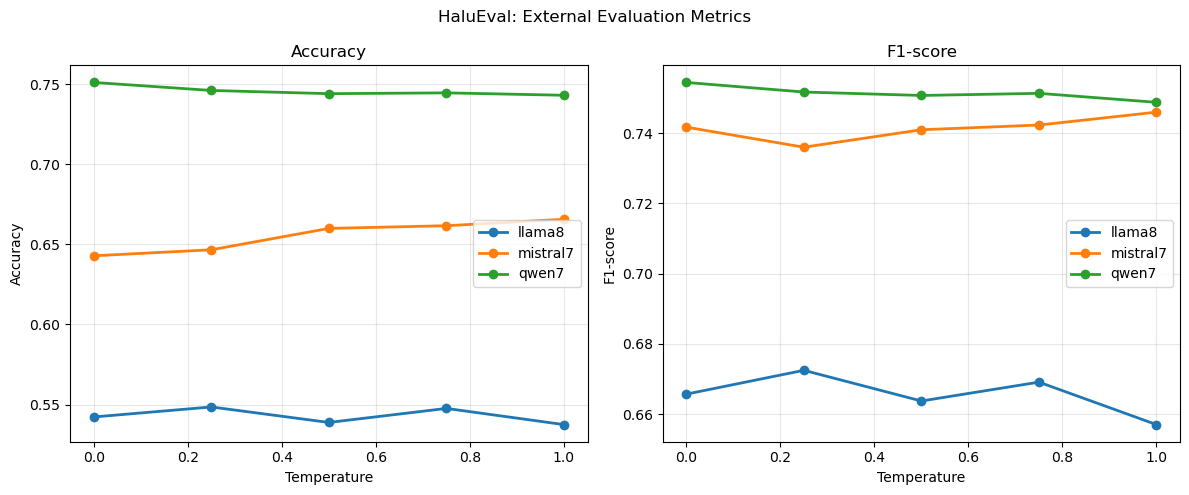

In [67]:
# ============================================================
# HaluEval External Metrics Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for judge in halueval_external_metrics["judge_model"].unique():

    df = (
        halueval_external_metrics[
            halueval_external_metrics["judge_model"] == judge
        ]
        .sort_values("temperature")
    )

    axes[0].plot(
        df["temperature"],
        df["accuracy"],
        marker="o",
        linewidth=2,
        label=judge
    )

    axes[1].plot(
        df["temperature"],
        df["f1"],
        marker="o",
        linewidth=2,
        label=judge
    )

axes[0].set_title("Accuracy")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("F1-score")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("F1-score")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("HaluEval: External Evaluation Metrics")
plt.tight_layout()

plt.savefig(
    "halueval_external_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# external

In [78]:
sorted(results_df["prediction_norm"].dropna().unique())

sorted(results_df["ground_truth_norm"].dropna().unique())

results_df["prediction_norm"].value_counts()

results_df["ground_truth_norm"].value_counts()

ground_truth_norm
pass    109623
fail    109623
Name: count, dtype: int64

In [76]:
sorted(results_df["prediction_norm"].dropna().unique())

['fail', 'invalid', 'pass']

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

single_run_metrics = (
    results_df[results_df["mode"] == "multirun"]
    .groupby(["judge_model", "generator_model", "temperature", "run_id"])
    .apply(
        lambda df: pd.Series({
            "accuracy": accuracy_score(
                df["ground_truth_norm"],
                df["prediction_norm"]
            ),
            "precision": precision_score(
                df["ground_truth_norm"],
                df["prediction_norm"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "recall": recall_score(
                df["ground_truth_norm"],
                df["prediction_norm"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "f1": f1_score(
                df["ground_truth_norm"],
                df["prediction_norm"],
                pos_label="pass",
                average="binary",
                zero_division=0
            )
        })
    )
    .reset_index()
)

single_run_summary = (
    single_run_metrics
    .groupby(["judge_model","generator_model","temperature"])
    .agg(
        accuracy=("accuracy","mean"),
        precision=("precision","mean"),
        recall=("recall","mean"),
        f1=("f1","mean")
    )
    .reset_index()
)

single_run_summary.round(4)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [69]:
majority_metrics = (
    model_temp_predictions
    .groupby(["judge_model","generator_model","temperature"])
    .apply(
        lambda df: pd.Series({
            "accuracy": accuracy_score(
                df["ground_truth_norm"],
                df["model_prediction"]
            ),
            "precision": precision_score(
                df["ground_truth_norm"],
                df["model_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "recall": recall_score(
                df["ground_truth_norm"],
                df["model_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "f1": f1_score(
                df["ground_truth_norm"],
                df["model_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            )
        })
    )
    .reset_index()
)

majority_metrics.round(4)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [70]:
simple_ensemble_metrics = (
    judge_votes_complete
    .groupby("temperature")
    .apply(
        lambda df: pd.Series({
            "accuracy": accuracy_score(
                df["ground_truth_norm"],
                df["ensemble_majority_prediction"]
            ),
            "precision": precision_score(
                df["ground_truth_norm"],
                df["ensemble_majority_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "recall": recall_score(
                df["ground_truth_norm"],
                df["ensemble_majority_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "f1": f1_score(
                df["ground_truth_norm"],
                df["ensemble_majority_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            )
        })
    )
    .reset_index()
)

simple_ensemble_metrics.round(4)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [71]:
weighted_metrics = (
    judge_votes_weighted
    .groupby("temperature")
    .apply(
        lambda df: pd.Series({
            "accuracy": accuracy_score(
                df["ground_truth_norm"],
                df["weighted_prediction"]
            ),
            "precision": precision_score(
                df["ground_truth_norm"],
                df["weighted_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "recall": recall_score(
                df["ground_truth_norm"],
                df["weighted_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            ),
            "f1": f1_score(
                df["ground_truth_norm"],
                df["weighted_prediction"],
                pos_label="pass",
                average="binary",
                zero_division=0
            )
        })
    )
    .reset_index()
)

weighted_metrics.round(4)

C:\Users\georg\AppData\Local\Temp\ipykernel_18840\74568428.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,temperature,accuracy,precision,recall,f1
0,0.00,0.6765,0.6181,0.9240,0.7407
1,0.25,0.6615,0.6047,0.9330,0.7338
2,0.50,0.6590,0.6045,0.9200,0.7296
3,0.75,0.6755,0.6155,0.9350,0.7424
4,1.00,0.6783,0.6204,0.9185,0.7406


In [72]:
# ============================================================
# Comparison of aggregation methods
# ============================================================

comparison_metrics = (
    simple_ensemble_metrics
    .merge(
        weighted_metrics,
        on="temperature",
        suffixes=("_simple", "_weighted")
    )
)

comparison_metrics = comparison_metrics.round(4)

display(comparison_metrics)

NameError: name 'simple_ensemble_metrics' is not defined

In [73]:
plt.figure(figsize=(9,5.5))

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["precision_simple"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Simple Majority"
)

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["precision_weighted"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Weighted Majority"
)

plt.xlabel("Temperature")
plt.ylabel("Precision")
plt.title("HaluEval: Precision Comparison")

plt.xticks(comparison_metrics["temperature"])

plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "precision_simple_vs_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'comparison_metrics' is not defined

<Figure size 900x550 with 0 Axes>

In [74]:
plt.figure(figsize=(9,5.5))

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["recall_simple"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Simple Majority"
)

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["recall_weighted"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Weighted Majority"
)

plt.xlabel("Temperature")
plt.ylabel("Recall")
plt.title("HaluEval: Recall Comparison")

plt.xticks(comparison_metrics["temperature"])

plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "recall_simple_vs_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'comparison_metrics' is not defined

<Figure size 900x550 with 0 Axes>

In [75]:
plt.figure(figsize=(9,5.5))

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["f1_simple"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Simple Majority"
)

plt.plot(
    comparison_metrics["temperature"],
    comparison_metrics["f1_weighted"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    markersize=7,
    label="Weighted Majority"
)

plt.xlabel("Temperature")
plt.ylabel("F1 Score")
plt.title("HaluEval: F1 Comparison")

plt.xticks(comparison_metrics["temperature"])

plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "f1_simple_vs_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'comparison_metrics' is not defined

<Figure size 900x550 with 0 Axes>